# Mining Hidden Structure in Recipes

## Project introduction

This project studies recipe behavior through multiple representations of the same data. A recipe can be represented as an ingredient list, as an ordered sequence of cooking steps, and as a text document. Each representation captures a different aspect of the recipe. The main goal of the project is to use these different representations, together with different data mining techniques, to observe which kinds of recipe structure remain stable and which kinds change across views.

The project is built around methods taught in class, combined with selected external methods where needed. This makes the project both a comparison of recipe representations and a comparison of how different data mining techniques behave on the same underlying objects.

## Motivation

The Food.com dataset is a good fit for this goal because each recipe includes ingredients, cooking steps, and text. That makes it possible to analyze the same recipes from several angles. Earlier exploration showed that the interaction side of the data is very sparse, while the recipe content side is much richer. Because of that, the final project focuses on recipe content rather than user–item behavior.

The main motivation is to observe how recipe structure changes depending on representation and method. Ingredient overlap, step order, and text semantics do not capture the same information. Some patterns are visible only in unordered ingredient baskets. Some appear only when step order is preserved. Some become clearer only when recipes are viewed as communities or text topics. Using multiple representations and multiple techniques makes it possible to compare those behaviors directly.

## Research questions

### RQ1
**How much agreement is there between recipe clusters built from ingredient features and recipe clusters built from step-text features?**

This question uses two different representations of the same recipes and applies clustering to both. The goal is to compare how ingredient-based grouping and procedure-based grouping behave.

### RQ2
**Among recipes sharing a frequent ingredient itemset, what frequent step subsequences recur, and how concentrated are those procedural patterns?**

This question moves from unordered ingredient baskets to ordered step sequences. It combines frequent itemset mining and sequential pattern mining to compare what is visible in unordered versus ordered representations.

### RQ3
**Do recipe groups formed from ingredient similarity align with text topics from recipe descriptions and steps?**

This question compares ingredient-based graph structure with text-based semantic structure. It uses graph mining and topic modeling to study whether broad recipe groups remain consistent across those two views.

## Role of course techniques and external techniques

A central part of the project is the use of different data mining techniques on different recipe representations.

- **Clustering** is used in RQ1 to compare ingredient-based and step-text-based recipe families.
- **Frequent itemset mining** is used in RQ2 to study common ingredient combinations.
- **Graph mining** is used in RQ3 to study ingredient-based recipe communities.

These are paired with external techniques where the question requires them.

- **Sequential pattern mining** is used in RQ2 because recipe steps are naturally ordered.
- **Topic modeling** is used in RQ3 because the text side is about broader semantic themes rather than only clustering.

This design makes the project a direct comparison of what different methods reveal when the same recipes are represented in different ways.

## Project development from earlier checkpoints

### Checkpoint 1

Checkpoint 1 focused on understanding the dataset and deciding the project direction. The main conclusion was that the user–recipe interaction side was too sparse to be the center of the project. The recipe side was much more suitable because it contained ingredients, steps, and text for a large number of recipes.

Checkpoint 1 also showed that the ingredient vocabulary was large and highly imbalanced, with common pantry items appearing across many recipes. That observation influenced later representation choices and motivated weighted ingredient features instead of relying only on raw frequency.

### Checkpoint 2

Checkpoint 2 turned that direction into concrete research questions and method choices. It established the final three-question structure of the project and tested whether each question was workable.

For RQ1, early experiments showed that ingredient-based and step-based representations could be built on the same recipes and compared using clustering.

For RQ2, early experiments showed that frequent ingredient combinations could be linked to recurring ordered step patterns, which justified combining frequent itemset mining with sequential pattern mining.

For RQ3, early experiments showed that ingredient-based graph communities and text-based themes could be compared in a meaningful way, which justified combining graph mining with topic modeling.

These checkpoint results shaped the final notebook. They narrowed the project to the recipe side, confirmed that multiple representations were necessary, and guided the final choice of methods.


## Dataset

### Food.com


#### Dataset size and structure

* It contains 231,637 recipes with ingredient lists, recipe names, tags, nutrition metadata, descriptions, and cooking steps. Each recipe can be viewed both as an ingredient basket and as a text document. It also contains 718,379 user recipe interactions. The interaction side is user item rating data, and the two are linked by recipe identifiers.

#### Licensing
* Kaggle dataset license is listed as Data files © Original Authors with author Shuyang Li- UCSD PhD researcher

Downloading the dataset

In [78]:
import os
from pathlib import Path

src = Path("kaggle.json")
assert src.exists(), "Upload kaggle.json first."

kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(parents=True, exist_ok=True)

dst = kaggle_dir / "kaggle.json"
dst.write_bytes(src.read_bytes())
os.chmod(dst, 0o600)

DATASET = "shuyangli94/food-com-recipes-and-user-interactions"
OUT_DIR = Path("data/foodcom")
OUT_DIR.mkdir(parents=True, exist_ok=True)

!kaggle datasets download -d {DATASET} -p {OUT_DIR} --unzip
print("Downloaded into:", OUT_DIR.resolve())

Dataset URL: https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions
License(s): copyright-authors
food-com-recipes-and-user-interactions.zip: Skipping, found more recently modified local copy (use --force to force download)
Downloaded into: /content/data/foodcom


In [55]:
import ast
import re
import math
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score
)
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.neighbors import kneighbors_graph

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

Loading Raw Data

In [88]:
root = Path("data/foodcom")

raw_recipes = pd.read_csv(root / "RAW_recipes.csv", low_memory=False)
raw_interactions = pd.read_csv(root / "RAW_interactions.csv", low_memory=False)

print("RAW_recipes:", raw_recipes.shape)
print("RAW_interactions:", raw_interactions.shape)
raw_recipes.head(2)

RAW_recipes: (231637, 12)
RAW_interactions: (1132367, 5)


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6


## Shared preprocessing

This notebook first builds one shared cleaned recipe table that is reused across all three research questions.

The shared preprocessing keeps both **raw** and **normalized** versions of the ingredient representation. This is useful because the project uses different representations and different data mining techniques on the same recipes. The shared table also creates common step-text and action-sequence fields so that later sections can branch cleanly into RQ-specific analysis without repeating the same data preparation logic.

In [89]:
import ast
import re
import math
import unicodedata
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

These helper functions support all three research questions.

- `parse_list_col` converts list-like strings from the raw CSV into Python lists.
- `clean_text` creates a consistent lowercase text representation.
- `normalize_ingredient` builds a mild canonical ingredient form that is useful across clustering, itemset mining, and graph construction.
- `normalize_actions_base` creates a shared action-sequence representation from recipe steps.
- `remove_ingredient_tokens_from_text` removes ingredient words from step text so the step side can focus more on procedure instead of simply repeating ingredient names.

In [98]:
def parse_list_col(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

def clean_text(s):
    s = str(s).lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("utf-8")
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def ingredient_token_set(ingredients_list):
    toks = set()
    for ing in ingredients_list:
        toks.update(clean_text(ing).split())
    return toks

def remove_ingredient_tokens_from_text(text, ingredient_tokens):
    if not text:
        return ""
    toks = [tok for tok in text.split() if tok not in ingredient_tokens]
    return " ".join(toks)

This cell creates the base recipe table used across the notebook.

It keeps only the preprocessing that is clearly shared across all three research questions.

The shared table includes:
- raw parsed ingredient lists
- cleaned step text
- cleaned description text
- ingredient token sets from the raw ingredient lists
- step text with raw ingredient words removed
- full document text
- document text with ingredient words removed

More aggressive ingredient normalization and action-sequence construction are not done here. Those are added later only in the sections that need them.

In [99]:
recipes = raw_recipes[["id", "name", "ingredients", "steps", "description"]].copy()

recipes["ingredients_list_raw"] = recipes["ingredients"].apply(parse_list_col)
recipes["steps_list"] = recipes["steps"].apply(parse_list_col)

recipes = recipes[
    (recipes["ingredients_list_raw"].str.len() > 0) &
    (recipes["steps_list"].str.len() > 0)
].copy()

recipes["desc_clean"] = recipes["description"].fillna("").astype(str).apply(clean_text)
recipes["step_text_clean"] = recipes["steps_list"].apply(lambda xs: clean_text(" ".join(xs)))

recipes["ingredient_token_set_raw"] = recipes["ingredients_list_raw"].apply(ingredient_token_set)

recipes["step_text_no_ing_raw"] = recipes.apply(
    lambda row: remove_ingredient_tokens_from_text(
        row["step_text_clean"],
        row["ingredient_token_set_raw"]
    ),
    axis=1
)

recipes["doc_text_full"] = (
    recipes["desc_clean"] + " " + recipes["step_text_clean"]
).str.strip()

recipes["doc_text_no_ing_raw"] = (
    recipes["desc_clean"] + " " + recipes["step_text_no_ing_raw"]
).str.strip()

recipes = recipes.reset_index(drop=True)

print(recipes.shape)

(231636, 13)


- `ingredients_list_raw` preserves the original ingredient list.
- `step_text_clean` gives a cleaned version of the cooking instructions.
- `ingredient_token_set_raw` is used to remove ingredient words from the step text.
- `step_text_no_ing_raw` reduces ingredient leakage on the step side.
- `doc_text_full` keeps the full description-plus-step text.
- `doc_text_no_ing_raw` keeps the text version with ingredient words removed.

This shared table is the common base for all three research questions.

In [101]:
recipes[
    [
        "name",
        "ingredients_list_raw",
        "step_text_clean",
        "step_text_no_ing_raw",
        "doc_text_full",
        "doc_text_no_ing_raw"
    ]
].head(3)

,name,ingredients_list_raw,step_text_clean,step_text_no_ing_raw,doc_text_full,doc_text_no_ing_raw
0,arriba baked winter squash mexican style,"[winter squash, mexican seasoning, mixed spice...",make a choice and proceed with recipe dependin...,make a choice and proceed with recipe dependin...,autumn is my favorite time of year to cook thi...,autumn is my favorite time of year to cook thi...
1,a bit different breakfast pizza,"[prepared pizza crust, sausage patty, eggs, mi...",preheat oven to degrees f press dough into the...,preheat oven to degrees f press dough into the...,this recipe calls for the crust to be prebaked...,this recipe calls for the crust to be prebaked...
2,all in the kitchen chili,"[ground beef, yellow onions, diced tomatoes, t...",brown ground beef in large pot add chopped oni...,brown in large pot add chopped to when almost ...,this modified version of mom s chili was a hit...,this modified version of mom s chili was a hit...


At this stage, the notebook has one shared cleaned recipe table that supports all three research questions.

From here:
- **RQ1** can use the raw ingredient lists and the ingredient-removed step text.
- **RQ2** can add its own ingredient normalization and action-sequence construction before itemset mining and sequence mining.
- **RQ3** can use the raw ingredient lists for ingredient similarity and use the full or ingredient-removed document text for topic modeling.

This keeps the shared preprocessing simple and makes the RQ-specific preprocessing easier to justify.

## RQ1: Ingredient-based clusters versus step-text clusters

### Research question
**How much agreement is there between recipe clusters built from ingredient features and recipe clusters built from step-text features?**

This section compares two recipe-level views directly.

- The **ingredient view** represents recipes by ingredient composition.
- The **step-text view** represents recipes by the language of the cooking steps after removing recipe-specific ingredient words.

This design follows the main RQ1 goal from the earlier project plan: compare ingredient-based grouping and procedure-based grouping on the same recipes.


I use **TF-IDF** on both sides so very common tokens do not dominate similarity. On the ingredient side, this reduces the influence of common pantry items. On the step side, this reduces the influence of very common procedural words.

I use **Truncated SVD** to reduce both sparse matrices into lower-dimensional dense representations. This makes clustering more stable and easier to compute.

I use **HAC** and **k-means** because clustering is one of the main course technique for this question. HAC is useful when cluster shapes may be less spherical, while k-means provides a standard baseline.

I compare the resulting partitions with **ARI** and **NMI**, and I also inspect cluster balance and cluster content so the interpretation does not rely only on one score table.

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

def identity(x):
    return x

def reduce_dim(X, n_components=50):
    max_comp = min(n_components, X.shape[0] - 1, X.shape[1] - 1)
    return TruncatedSVD(n_components=max_comp, random_state=42).fit_transform(X)

def cluster_and_compare(X_a, X_b, k, method="hac"):
    if method == "hac":
        labels_a = AgglomerativeClustering(
            n_clusters=k,
            metric="cosine",
            linkage="average"
        ).fit_predict(X_a)

        labels_b = AgglomerativeClustering(
            n_clusters=k,
            metric="cosine",
            linkage="average"
        ).fit_predict(X_b)

    elif method == "kmeans":
        labels_a = KMeans(
            n_clusters=k,
            n_init=20,
            random_state=42
        ).fit_predict(X_a)

        labels_b = KMeans(
            n_clusters=k,
            n_init=20,
            random_state=42
        ).fit_predict(X_b)
    else:
        raise ValueError("method must be 'hac' or 'kmeans'")

    sizes_a = pd.Series(labels_a).value_counts().sort_index()
    sizes_b = pd.Series(labels_b).value_counts().sort_index()

    return {
        "labels_a": labels_a,
        "labels_b": labels_b,
        "ARI": adjusted_rand_score(labels_a, labels_b),
        "NMI": normalized_mutual_info_score(labels_a, labels_b),
        "silhouette_a": silhouette_score(X_a, labels_a),
        "silhouette_b": silhouette_score(X_b, labels_b),
        "sizes_a": sizes_a,
        "sizes_b": sizes_b,
    }

def top_terms_by_cluster(X, labels, feature_names, top_n=10):
    rows = []
    for c in sorted(pd.unique(labels)):
        idx = np.where(labels == c)[0]
        mean_vec = np.asarray(X[idx].mean(axis=0)).ravel()
        top_idx = mean_vec.argsort()[::-1][:top_n]
        rows.append({
            "cluster": c,
            "size": len(idx),
            "top_terms": ", ".join(feature_names[top_idx])
        })
    return pd.DataFrame(rows)

def sample_names_by_cluster(df, label_col, n=5):
    rows = []
    for c in sorted(df[label_col].unique()):
        sample_names = df.loc[df[label_col] == c, "name"].head(n).tolist()
        rows.append({
            "cluster": c,
            "sample_recipes": sample_names
        })
    return pd.DataFrame(rows)

def jaccard(a, b):
    a, b = set(a), set(b)
    inter = len(a & b)
    union = len(a | b)
    return inter / union if union > 0 else 0.0

This experiment uses the shared recipe table from the common preprocessing section.

- On the ingredient side, I use the raw ingredient list representation.
- On the step side, I use step text with ingredient words removed, because the goal is to capture procedure more than repeated food-content words.

I keep a single large recipe sample for the final analysis so that the comparison is large enough to be meaningful, but still practical to run in Colab.

In [63]:
RANDOM_STATE = 42
K_VALUES = [8, 12, 16, 20]
RQ1_SAMPLE_N = 25000

rq1 = recipes[
    (recipes["ingredients_list_raw"].str.len() > 0) &
    (recipes["step_text_no_ing_raw"].str.len() > 0)
].copy()

rq1 = rq1.sample(RQ1_SAMPLE_N, random_state=RANDOM_STATE).reset_index(drop=True)

vec_ing_tfidf = TfidfVectorizer(
    tokenizer=identity,
    preprocessor=identity,
    token_pattern=None,
    lowercase=False,
    min_df=10
)

vec_step_text = TfidfVectorizer(
    stop_words="english",
    min_df=5,
    max_df=0.6,
    ngram_range=(1, 2)
)

X_ing_tfidf = vec_ing_tfidf.fit_transform(rq1["ingredients_list_raw"])
X_step_text = vec_step_text.fit_transform(rq1["step_text_no_ing_raw"])

mask_main = (X_ing_tfidf.getnnz(axis=1) > 0) & (X_step_text.getnnz(axis=1) > 0)

rq1_main = rq1.loc[mask_main].reset_index(drop=True)
X_ing_tfidf_main = X_ing_tfidf[mask_main]
X_step_text_main = X_step_text[mask_main]

X_ing_tfidf_red_main = reduce_dim(X_ing_tfidf_main, 50)
X_step_text_red_main = reduce_dim(X_step_text_main, 50)

print("Rows kept for RQ1:", len(rq1_main))
print("Ingredient TF-IDF shape:", X_ing_tfidf_main.shape)
print("Step-text TF-IDF shape:", X_step_text_main.shape)

Rows kept for RQ1: 24976
Ingredient TF-IDF shape: (24976, 1973)
Step-text TF-IDF shape: (24976, 31815)


The table below compares clustering agreement across methods and values of `k`.

- **ARI** and **NMI** measure agreement between the ingredient-based and step-based partitions.
- **Silhouette** is used as an internal quality check within each view.
- The largest-cluster fraction is included to show whether one representation is collapsing too much of the data into one broad group.

In [64]:
rq1_main_results = []

for method in ["kmeans", "hac"]:
    for k in K_VALUES:
        out = cluster_and_compare(X_ing_tfidf_red_main, X_step_text_red_main, k=k, method=method)

        rq1_main_results.append({
            "pair": "ingredient_tfidf_vs_step_text",
            "method": method,
            "k": k,
            "ARI": out["ARI"],
            "NMI": out["NMI"],
            "silhouette_ing": out["silhouette_a"],
            "silhouette_step": out["silhouette_b"],
            "largest_cluster_frac_ing": out["sizes_a"].max() / out["sizes_a"].sum(),
            "largest_cluster_frac_step": out["sizes_b"].max() / out["sizes_b"].sum(),
            "labels_ing": out["labels_a"],
            "labels_step": out["labels_b"],
            "sizes_ing": out["sizes_a"],
            "sizes_step": out["sizes_b"],
        })

rq1_main_df = pd.DataFrame([
    {
        "Method": r["method"],
        "k": r["k"],
        "ARI": r["ARI"],
        "NMI": r["NMI"],
        "Silhouette ingredient": r["silhouette_ing"],
        "Silhouette step": r["silhouette_step"],
        "Largest cluster frac ingredient": r["largest_cluster_frac_ing"],
        "Largest cluster frac step": r["largest_cluster_frac_step"],
    }
    for r in rq1_main_results
]).sort_values(["Method", "k"]).reset_index(drop=True)

rq1_main_df

,Method,k,ARI,NMI,Silhouette ingredient,Silhouette step,Largest cluster frac ingredient,Largest cluster frac step
0,hac,8,0.091814,0.068151,-0.051534,-0.035899,0.347854,0.389814
1,hac,12,0.080312,0.067927,-0.034173,-0.034089,0.347854,0.375360
2,hac,16,0.086463,0.077443,-0.115865,-0.025952,0.311379,0.342689
3,hac,20,0.089787,0.096362,-0.098335,-0.025766,0.240991,0.317064
4,kmeans,8,0.093612,0.120921,0.046944,0.074791,0.388773,0.299087
5,kmeans,12,0.052344,0.116287,0.053796,0.064769,0.316864,0.243674
6,kmeans,16,0.038013,0.107465,0.052114,0.072642,0.253804,0.212404
7,kmeans,20,0.039261,0.122132,0.041928,0.087236,0.185418,0.159193


The agreement between ingredient-based clusters and step-text clusters is modest across all settings.

A few patterns stand out.

- NMI is always higher than ARI. This means the two views share some broad recipe-family structure, but they do not match closely as exact one-to-one partitions.
- k-means gives the highest NMI around 0.11 to 0.12
- HAC gives slightly stronger ARI for `k = 12`, `16`, and `20`, but the differences are small.
- k-means also has better silhouette scores HAC has negative silhouette values throughout, so its clusters are less cleanly separated in the reduced feature space.
- The largest cluster fractions are still fairly high, especially at smaller values of `k`, so both views contain a few broad groups rather than many balanced categories.

For this dataset, NMI is more important than ARI for interpretation. I do not expect ingredient-based groups and step-based groups to match exactly. I care more about whether they recover the same broad recipe families. NMI captures that better, while ARI is stricter and drops more when the two views split the same family in different ways.

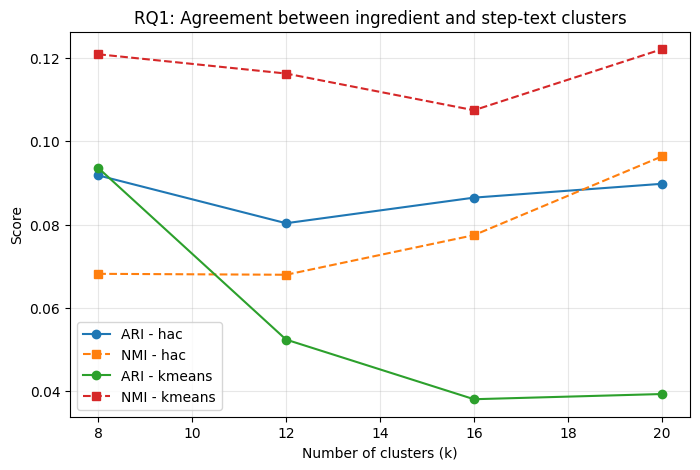

In [65]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_df = rq1_main_df.copy()

for method in plot_df["Method"].unique():
    sub = plot_df[plot_df["Method"] == method].sort_values("k")
    ax.plot(sub["k"], sub["ARI"], marker="o", label=f"ARI - {method}")
    ax.plot(sub["k"], sub["NMI"], marker="s", linestyle="--", label=f"NMI - {method}")

ax.set_title("RQ1: Agreement between ingredient and step-text clusters")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Score")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

The line plot shows that the main story is stable across values of `k`.

- The agreement does not become strong at any setting.
- The k-means NMI curve stays consistently above HAC.
- The HAC ARI values stay fairly flat, while the k-means ARI values drop as `k` increases.
- This means the two views keep some broad shared structure, but the exact partition becomes less stable as the number of clusters increases.

The ingredient view and the step-text view are related, but the match is only partial.

I use HAC with `k = 8` as the main run for interpretation.

This is not because it gives the best value on every metric. It does not. The main reason is interpretability.

- `k = 8` keeps the number of families small enough to inspect directly.
- At higher values of `k`, the groups become harder to summarize cleanly in a curated notebook.
- HAC at `k = 8` gives a readable family-level partition that works well for the overlap heatmaps and the qualitative examples.

The main conclusion does not depend on this one run. The metric table already showed that the overall agreement stays modest across methods and values of `k`. This representative run is used to explain where the overlap is concentrated andwhat kinds of families appear on the two sides.

In [66]:
chosen_method = "hac"
chosen_k = 8

best_row = next(
    r for r in rq1_main_results
    if r["method"] == chosen_method and r["k"] == chosen_k
)

labels_ing = best_row["labels_ing"]
labels_step = best_row["labels_step"]

rq1_best = rq1_main.copy()
rq1_best["ing_cluster"] = labels_ing
rq1_best["step_cluster"] = labels_step

sizes_ing = best_row["sizes_ing"]
sizes_step = best_row["sizes_step"]

Cluster sizes provide a first view of how balanced or uneven the two partitions are. This is useful because a representation can appear to cluster reasonably while still collapsing a large fraction of recipes into one or two broad groups.

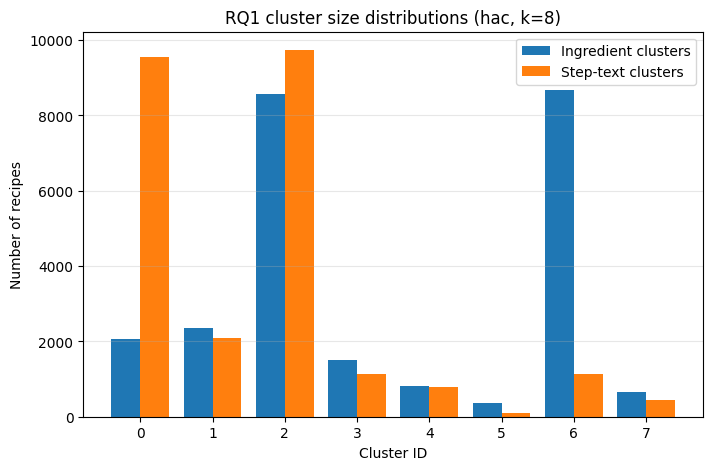

In [67]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(sizes_ing.index - 0.2, sizes_ing.values, width=0.4, label="Ingredient clusters")
ax.bar(sizes_step.index + 0.2, sizes_step.values, width=0.4, label="Step-text clusters")

ax.set_title(f"RQ1 cluster size distributions ({chosen_method}, k={chosen_k})")
ax.set_xlabel("Cluster ID")
ax.set_ylabel("Number of recipes")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.show()

The cluster size plot shows that both views are uneven.

- On the ingredient side, a few large clusters dominate the dataset.
- On the step-text side, a few broad procedural groups also dominate.
- This means the recipe space is organized around some large general families, not many evenly sized categories.

That matters for interpretation. It explains why exact cluster agreement is limited. If one view forms broad pantry-style groups and the other forms broad procedure-style groups, partial overlap is more realistic than exact matching.

The tables below summarize the main ingredient identities and the main step-text identities of the clusters. This makes it possible to interpret which recipe families align across the two views and which ones split across different procedures.

In [68]:
ing_feature_names = np.array(vec_ing_tfidf.get_feature_names_out())
step_feature_names = np.array(vec_step_text.get_feature_names_out())

ingredient_cluster_terms = top_terms_by_cluster(
    X_ing_tfidf_main, labels_ing, ing_feature_names, top_n=10
)

step_cluster_terms = top_terms_by_cluster(
    X_step_text_main, labels_step, step_feature_names, top_n=10
)

ingredient_cluster_terms

,cluster,size,top_terms
0,0,2056,"oil, vegetable oil, soy sauce, salt, water, su..."
1,1,2363,"cheddar cheese, bacon, sour cream, mayonnaise,..."
2,2,8567,"sugar, butter, salt, eggs, baking powder, flou..."
3,3,1493,"honey, orange juice, banana, ice, vodka, soy s..."
4,4,805,"brown sugar, worcestershire sauce, ketchup, on..."
5,5,359,"walnuts, bananas, peanut butter, butter, semi-..."
6,6,8688,"olive oil, salt, onion, garlic cloves, pepper,..."
7,7,645,"lemon juice, olive oil, sugar, salt, water, bu..."


In [69]:
step_cluster_terms

,cluster,size,top_terms
0,0,9552,"bake, oven, pan, bowl, mixture, mix, place, do..."
1,1,2098,"mix, ingredients, dressing, bowl, combine, mix..."
2,2,9736,"heat, cook, stir, simmer, medium, boil, skille..."
3,3,1139,"grill, marinade, fish, bag, place, heat, turni..."
4,4,785,"cooker, crock, hours, crock pot, slow cooker, ..."
5,5,105,"machine, cycle, order, manufacturer, basic, in..."
6,6,1123,"blender, blend, processor, food, food processo..."
7,7,438,"glass, ice, shaker, shake, pour, cocktail, gar..."


In [70]:
ingredient_cluster_samples = sample_names_by_cluster(rq1_best, "ing_cluster", n=5)
step_cluster_samples = sample_names_by_cluster(rq1_best, "step_cluster", n=5)

ingredient_cluster_samples

,cluster,sample_recipes
0,0,"[szechuan noodles with minced beef, bahama bre..."
1,1,"[crab spinach casserole, pilgrim s sandwich sp..."
2,2,"[buttercream frosting decorators icing, cream..."
3,3,"[christmas heat, pinky lady lemonade cocktail,..."
4,4,"[mixed barbecue sauce, nanas remoulade sauce, ..."
5,5,"[applebee s maple butter sauce, laurie s micro..."
6,6,"[curried beef, delicious steamed whole articho..."
7,7,"[black widow spider, sunshine rice, viva madri..."


In [71]:
step_cluster_samples

,cluster,sample_recipes
0,0,"[delicious steamed whole artichokes, pork tend..."
1,1,"[mixed barbecue sauce, lamb patties with yoghu..."
2,2,"[crab spinach casserole, curried beef, creamy ..."
3,3,"[barbecue cola chicken, coconut chicken and pi..."
4,4,"[chicken provencal stew in the crock pot, rose..."
5,5,"[onion rye loaf bread machine, jessica s milk..."
6,6,"[pilgrim s sandwich spread, black widow spider..."
7,7,"[pinky lady lemonade cocktail, lights of havan..."


The step side is easier to interpret as procedure.

The major step clusters are:

- a broad oven-bake group
- a mix / assemble group
- a stovetop / simmer group
- a grill / marinade group
- a slow-cooker group
- a blender / processor group
- a drink / cocktail group

This is useful because it shows what the step-text view is actually capturing. It is grouping recipes by how they are prepared, not mainly by ingredients.

The ingredient side is broader. It tends to group recipes by shared ingredient backbones rather than by one exact dish type. That difference is important for the rest of the analysis.

In [72]:
cross_tab_row = cross_tab.div(cross_tab.sum(axis=1), axis=0)
cross_tab_col = cross_tab.div(cross_tab.sum(axis=0), axis=1)

row_top2 = []
for ing_c, row in cross_tab_row.iterrows():
    top = row.sort_values(ascending=False).head(2)
    row_top2.append({
        "ingredient_cluster": ing_c,
        "top_step_cluster_1": f"{top.index[0]} ({top.iloc[0]:.2f})",
        "top_step_cluster_2": f"{top.index[1]} ({top.iloc[1]:.2f})"
    })

col_top2 = []
for step_c, col in cross_tab_col.items():
    top = col.sort_values(ascending=False).head(2)
    col_top2.append({
        "step_cluster": step_c,
        "top_ingredient_cluster_1": f"{top.index[0]} ({top.iloc[0]:.2f})",
        "top_ingredient_cluster_2": f"{top.index[1]} ({top.iloc[1]:.2f})"
    })

row_top2_df = pd.DataFrame(row_top2)
col_top2_df = pd.DataFrame(col_top2)

display(row_top2_df)
display(col_top2_df)

,ingredient_cluster,top_step_cluster_1,top_step_cluster_2
0,0,2 (0.54),0 (0.23)
1,1,2 (0.38),0 (0.38)
2,2,0 (0.60),2 (0.25)
3,3,0 (0.24),2 (0.22)
4,4,2 (0.40),0 (0.28)
5,5,0 (0.43),2 (0.25)
6,6,2 (0.52),0 (0.25)
7,7,2 (0.40),0 (0.22)


,step_cluster,top_ingredient_cluster_1,top_ingredient_cluster_2
0,0,2 (0.54),6 (0.22)
1,1,6 (0.34),2 (0.22)
2,2,6 (0.47),2 (0.22)
3,3,6 (0.47),0 (0.14)
4,4,6 (0.49),2 (0.18)
5,5,2 (0.47),3 (0.21)
6,6,2 (0.33),6 (0.30)
7,7,3 (0.57),2 (0.27)


The cross-tab and normalized heatmaps show where the overlap is concentrated.

- The raw cross-tab shows how many recipes fall into each ingredient-cluster and step-cluster pairing.
- The row-normalized heatmap shows where each ingredient family goes on the procedure side.
- The column-normalized heatmap shows which ingredient families dominate each procedure family.

In [73]:
cross_tab = pd.crosstab(rq1_best["ing_cluster"], rq1_best["step_cluster"])
cross_tab

step_cluster,0,1,2,3,4,5,6,7
ing_cluster,,,,,,,,
0,466,175,1109,155,78,17,53,3
1,905,325,908,111,62,2,48,2
2,5161,459,2165,105,142,49,369,117
3,355,213,325,98,22,22,209,249
4,226,74,323,60,89,5,20,8
5,155,65,90,7,4,1,32,5
6,2145,705,4555,536,381,6,332,28
7,139,82,261,67,7,3,60,26


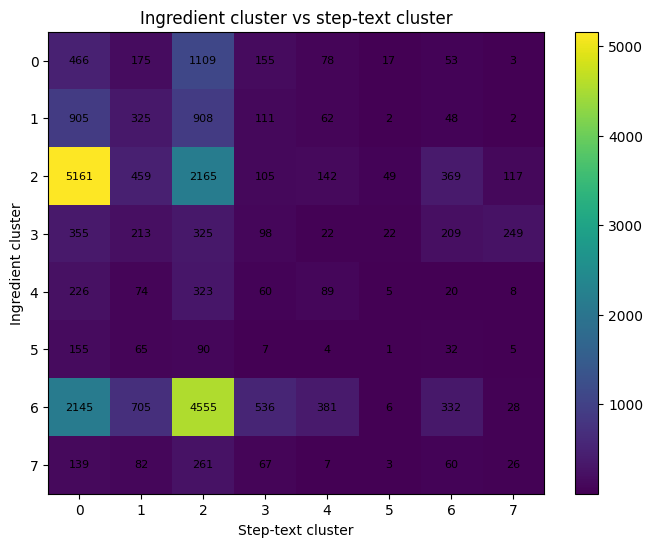

In [74]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cross_tab.values, aspect="auto")

ax.set_title("Ingredient cluster vs step-text cluster")
ax.set_xlabel("Step-text cluster")
ax.set_ylabel("Ingredient cluster")
ax.set_xticks(range(cross_tab.shape[1]))
ax.set_yticks(range(cross_tab.shape[0]))
ax.set_xticklabels(cross_tab.columns)
ax.set_yticklabels(cross_tab.index)

for i in range(cross_tab.shape[0]):
    for j in range(cross_tab.shape[1]):
        ax.text(j, i, str(cross_tab.iloc[i, j]), ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax)
plt.show()

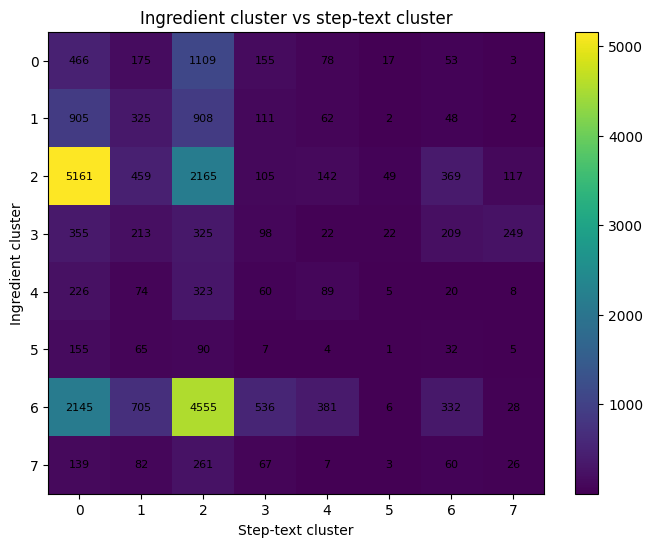

In [75]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cross_tab.values, aspect="auto")

ax.set_title("Ingredient cluster vs step-text cluster")
ax.set_xlabel("Step-text cluster")
ax.set_ylabel("Ingredient cluster")
ax.set_xticks(range(cross_tab.shape[1]))
ax.set_yticks(range(cross_tab.shape[0]))
ax.set_xticklabels(cross_tab.columns)
ax.set_yticklabels(cross_tab.index)

for i in range(cross_tab.shape[0]):
    for j in range(cross_tab.shape[1]):
        ax.text(j, i, str(cross_tab.iloc[i, j]), ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax)
plt.show()

The heatmaps show that the overlap is real, but it is not clean.

A few clear patterns appear.

- Some ingredient clusters split strongly across the two largest step clusters instead of mapping to one dominant procedure cluster.
- The biggest ingredient groups feed mainly into the broad oven-bake and stovetop / simmer step groups.
- Smaller step clusters such as grill / marinade, slow cooker, blender / processor, and drink / cocktail are more distinct on the procedure side, but they do not each come from one unique ingredient family.

This means ingredient similarity and procedural similarity are related, but the relationship is not one-to-one.

The row-normalized heatmap shows that an ingredient backbone often supports more than one procedure style.

The column-normalized heatmap shows the reverse pattern. Some procedure groups draw from more than one ingredient family.

That is the main RQ1 result: ingredient-procedure coupling is uneven across the recipe space.

The examples below illustrate recipe pairs that remain close in ingredient space but fall into different step-based clusters. These examples support the broader interpretation that similar ingredient backbones do not always produce the same procedure pattern.

In [76]:
from itertools import combinations

rows = []
MAX_PER_CLUSTER = 150

for c in sorted(rq1_best["ing_cluster"].unique()):
    sub = rq1_best[rq1_best["ing_cluster"] == c].reset_index(drop=True)
    sub = sub.iloc[:min(len(sub), MAX_PER_CLUSTER)].copy()

    for i, j in combinations(range(len(sub)), 2):
        ing_a = sub.loc[i, "ingredients_list_raw"]
        ing_b = sub.loc[j, "ingredients_list_raw"]

        jac = jaccard(ing_a, ing_b)

        if sub.loc[i, "step_cluster"] == sub.loc[j, "step_cluster"]:
            continue
        if jac < 0.40:
            continue

        shared = sorted(list(set(ing_a) & set(ing_b)))
        if len(shared) < 3:
            continue

        rows.append({
            "ing_cluster": c,
            "step_cluster_a": sub.loc[i, "step_cluster"],
            "step_cluster_b": sub.loc[j, "step_cluster"],
            "jaccard": jac,
            "name_a": sub.loc[i, "name"],
            "name_b": sub.loc[j, "name"],
            "actions_a": sub.loc[i, "actions_base_text"],
            "actions_b": sub.loc[j, "actions_base_text"],
            "shared_ingredients": shared
        })

pairs_df = pd.DataFrame(rows).sort_values(
    ["ing_cluster", "jaccard"], ascending=[True, False]
).reset_index(drop=True)

examples_same_ing_diff_step = (
    pairs_df.groupby("ing_cluster", as_index=False)
    .head(3)
    .reset_index(drop=True)
)

examples_same_ing_diff_step

,ing_cluster,step_cluster_a,step_cluster_b,jaccard,name_a,name_b,actions_a,actions_b,shared_ingredients
0,0,0,2,0.600000,best cheese biscuits,state fair mini corn dogs,mix prep bake serve,mix prep saute chill,"[all-purpose flour, baking powder, granulated ..."
1,0,1,2,0.500000,sesame soy vinaigrette,stir fried sesame asparagus,mix,mix saute serve,"[sesame oil, sesame seeds, soy sauce, sugar]"
2,0,3,1,0.416667,smoked ribs on the grill,asian vinaigrette salad dressing,mix boil,mix chill serve,"[garlic, peanut oil, rice wine vinegar, sesame..."
3,1,2,0,0.444444,maureen s stuffed peppers,rice stuffed bell peppers,boil bake,prep boil mix bake,"[cheddar cheese, cooked rice, green peppers, s..."
4,1,3,2,0.416667,alaskan parmesan baked halibut,mushroom gratin,mix bake,boil mix bake,"[butter, parmesan cheese, pepper, salt, sour c..."
5,1,4,0,0.400000,crock pot spinach special,savory eggs,mix boil,mix bake,"[butter, cheddar cheese, eggs, salt]"
6,2,0,1,0.470588,easy coffee cake,its the great pumpkin cookies charlie brown,mix bake,mix bake,"[baking soda, brown sugar, butter, cinnamon, f..."
7,2,2,0,0.444444,creamy cheesy scrambled eggs christmas morni...,buffet style fluffy oven scrambled eggs for a ...,boil mix serve,mix bake mix bake serve,"[butter, eggs, milk, salt]"
8,2,2,0,0.416667,creamy cheesy scrambled eggs christmas morni...,mini bacon egg cheese quiches,boil mix serve,mix bake chill mix bake,"[butter, cream cheese, milk, pepper, salt]"
9,3,3,0,0.400000,balsamic honey tenderloin,roasted onion wedges,mix chill boil prep,mix bake,"[balsamic vinegar, honey, pepper, salt]"


In [77]:
one_example_per_cluster = (
    examples_same_ing_diff_step
    .sort_values(["ing_cluster", "jaccard"], ascending=[True, False])
    .groupby("ing_cluster", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

one_example_per_cluster[[
    "ing_cluster", "step_cluster_a", "step_cluster_b", "jaccard",
    "name_a", "name_b", "actions_a", "actions_b", "shared_ingredients"
]]

,ing_cluster,step_cluster_a,step_cluster_b,jaccard,name_a,name_b,actions_a,actions_b,shared_ingredients
0,0,0,2,0.600000,best cheese biscuits,state fair mini corn dogs,mix prep bake serve,mix prep saute chill,"[all-purpose flour, baking powder, granulated ..."
1,1,2,0,0.444444,maureen s stuffed peppers,rice stuffed bell peppers,boil bake,prep boil mix bake,"[cheddar cheese, cooked rice, green peppers, s..."
2,2,0,1,0.470588,easy coffee cake,its the great pumpkin cookies charlie brown,mix bake,mix bake,"[baking soda, brown sugar, butter, cinnamon, f..."
3,3,3,0,0.400000,balsamic honey tenderloin,roasted onion wedges,mix chill boil prep,mix bake,"[balsamic vinegar, honey, pepper, salt]"
4,4,3,2,0.454545,barbecued ribs,best bbq sauce you ll ever taste southwest,bake chill mix chill mix boil serve,mix boil mix chill prep,"[chili powder, chili sauce, cider vinegar, dar..."
5,5,2,0,0.600000,crackle candy,choco scotch clusters,mix,,"[butterscotch chips, peanut butter, rice krisp..."
6,7,1,2,0.600000,our best lemonade,saskatoon pie filling,mix,boil mix boil,"[lemon juice, sugar, water]"


The example pairs make the same point in a more concrete way.

Several different kinds of branching appear:

- A shared baking base can branch into different outcomes.  
  For example, recipes like best cheese biscuits and state fair mini corn dogs share a strong baking-style ingredient backbone, but one follows a bake-oriented path while the other shifts toward a fry or saute style path.

- A shared stuffed-pepper or cheese-vegetable base can still split into different procedures.  
  Recipes such as maureen's stuffed peppers and rice stuffed bell peppers share a similar ingredient core, but the order and structure of the cooking steps differ.

- A sweet dessert base can branch into different dessert forms.  
  Recipes like easy coffee cake and pumpkin cookies stay close in ingredient space, but they do not land in exactly the same step-text family.

- A condiment or sauce-like base can branch even more.  
  Some pairs in the table share ingredients strongly but separate into sauce, glaze, side-dish, or dessert-like uses.

These examples show that the same ingredient backbone can support more than one procedural path. That is why the overall agreement stays modest even when the ingredient overlap is clearly real.

### Conclusion

RQ1 compared recipe families built from ingredients to recipe families built from step text.

The overall agreement was modest. NMI stayed higher than ARI across the experiments, which means the two views share some broad structure but do not match closely as exact partitions.

The cluster interpretation and the heatmaps show why. The ingredient side forms broad content-based groups, while the step side forms clearer procedure-based groups such as oven-bake, stovetop/simmer, grill/marinade, slow-cooker, blender, and drinks. Some ingredient families map mainly to one or two procedure groups, but many do not. They branch across multiple cooking styles.

The main result is that ingredient similarity and procedural similarity are related, but the strength of that relationship depends on the family. The coupling is partial, not global.

### Limitations and tradeoffs

This analysis is useful, but it also has clear limits.

- TF-IDF on ingredients reduces the influence of very common pantry items, but it still treats ingredients as tokens rather than richer culinary concepts.
- Step-text TF-IDF captures procedure language, but it also reflects writing style and recipe formatting.
- Removing ingredient words from the steps makes the procedure side cleaner, but it may also remove some useful context.
- NMI and ARI compare two partitions of the same recipes, but they do not tell us that one clustering is correct in an absolute sense.
- The result depends on representation choice and on `k`, which is why I compared several clustering settings instead of relying on one run only.

## RQ2: Frequent ingredient itemsets and recurring step subsequences

### Research question
**Among recipes sharing a frequent ingredient itemset, what frequent step subsequences recur, and how concentrated are those procedural patterns?**

RQ2 studies the same recipes in two different ways.

- On the ingredient side, each recipe is treated as an unordered basket.
- On the step side, each recipe is treated as an ordered sequence.

This is different from RQ1. RQ1 compared whole recipe families across two views. RQ2 focuses on what happens inside recipes that share the same ingredient set.

I use frequent itemset mining on the ingredient side because ingredient order does not matter. I use sequential pattern mining on the step side because the order of actions does matter.

Before running Apriori, I first inspect the ingredient vocabulary. This is important because frequent itemset mining depends directly on exact token matching, so small spelling and wording differences can split support across nearly identical ingredient forms.

In [102]:
rq2_base = recipes[
    (recipes["ingredients_list_raw"].str.len() > 0) &
    (recipes["steps_list"].str.len() > 0)
].copy().reset_index(drop=True)

print("RQ2 rows:", len(rq2_base))

RQ2 rows: 231636


RQ2 uses stronger ingredient normalization than the other sections because Apriori depends on exact item matching.

I inspected frequent ingredient variants in the dataset, drafted candidate rules with LLM assistance, and kept only rules that merged obvious wording variants of the same ingredient. The goal was to reduce support fragmentation without collapsing clearly different ingredients into one item.

In [114]:
import re
import unicodedata
from collections import Counter
import math
import time

def rq2_clean_text(s):
    s = str(s).lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("utf-8")
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

RQ2_DROP_WORDS = {
    "fresh", "dried", "dry", "plain", "whole", "raw",
    "minced", "chopped", "diced", "sliced", "crushed", "ground",
    "boneless", "skinless", "lean",
    "small", "medium", "large",
    "extra", "virgin"
}

RQ2_SURFACE_RULES = [
    (r"\beggs\b", "egg"),
    (r"\bgarlic cloves\b", "garlic"),
    (r"\bgarlic clove\b", "garlic"),
    (r"\bfresh garlic cloves\b", "garlic"),
    (r"\bfresh garlic clove\b", "garlic"),
    (r"\bminced garlic cloves\b", "garlic"),
    (r"\bminced garlic clove\b", "garlic"),
    (r"\bonions\b", "onion"),
    (r"\btomatoes\b", "tomato"),
    (r"\bpotatoes\b", "potato"),
    (r"\bcarrots\b", "carrot"),
    (r"\bextra virgin olive oil\b", "olive oil"),
    (r"\ball purpose flour\b", "flour"),
    (r"\bunbleached all purpose flour\b", "flour"),
    (r"\bplain flour\b", "flour"),
    (r"\ball purpose white flour\b", "flour"),
    (r"\bconfectioners sugar\b", "powdered sugar"),
    (r"\bicing sugar\b", "powdered sugar"),
    (r"\bfresh ground black pepper\b", "black pepper"),
    (r"\bground black pepper\b", "black pepper"),
    (r"\bfreshly ground black pepper\b", "black pepper"),
    (r"\bgreen onions\b", "green onion"),
    (r"\bscallions\b", "green onion"),
    (r"\bvanilla extract\b", "vanilla"),
]

RQ2_PROTECTED_PHRASES = [
    "olive oil",
    "vegetable oil",
    "sesame oil",
    "peanut oil",
    "coconut milk",
    "soy sauce",
    "fish sauce",
    "oyster sauce",
    "lemon juice",
    "lime juice",
    "baking powder",
    "baking soda",
    "brown sugar",
    "powdered sugar",
    "black pepper",
    "bell pepper",
    "chili powder",
    "curry powder",
    "garam masala",
    "cumin powder",
    "cream cheese",
    "sour cream",
    "green onion",
    "parmesan cheese",
    "cheddar cheese",
]

def rq2_apply_rules(text, rules):
    out = text
    for pat, repl in rules:
        out = re.sub(pat, repl, out)
    out = re.sub(r"\s+", " ", out).strip()
    return out

def rq2_simple_singularize_token(tok):
    if tok in {"eggs", "onions", "tomatoes", "potatoes", "carrots"}:
        return {
            "eggs": "egg",
            "onions": "onion",
            "tomatoes": "tomato",
            "potatoes": "potato",
            "carrots": "carrot",
        }[tok]
    return tok

def rq2_normalize_surface(ing):
    s = rq2_clean_text(ing)
    if not s:
        return ""

    s = rq2_apply_rules(s, RQ2_SURFACE_RULES)

    protected_map = {}
    for i, phrase in enumerate(RQ2_PROTECTED_PHRASES):
        placeholder = f"__P{i}__"
        if phrase in s:
            s = s.replace(phrase, placeholder)
            protected_map[placeholder] = phrase

    toks = []
    for tok in s.split():
        if tok in protected_map:
            toks.append(tok)
        else:
            tok = rq2_simple_singularize_token(tok)
            if tok not in RQ2_DROP_WORDS:
                toks.append(tok)

    s = " ".join(toks)

    for placeholder, phrase in protected_map.items():
        s = s.replace(placeholder, phrase)

    s = re.sub(r"\s+", " ", s).strip()
    return s

def rq2_normalize_ingredient_list(xs):
    out = []
    for x in xs:
        norm = rq2_normalize_surface(x)
        if norm:
            out.append(norm)
    return sorted(set(out))

In [116]:
rq2_base["ingredients_list_rq2"] = rq2_base["ingredients_list_raw"].apply(
    rq2_normalize_ingredient_list
)

rq2_base[["name", "ingredients_list_raw", "ingredients_list_rq2"]].head(3)

,name,ingredients_list_raw,ingredients_list_rq2
0,arriba baked winter squash mexican style,"[winter squash, mexican seasoning, mixed spice...","[butter, honey, mexican seasoning, mixed spice..."
1,a bit different breakfast pizza,"[prepared pizza crust, sausage patty, eggs, mi...","[cheese, egg, milk, prepared pizza crust, salt..."
2,all in the kitchen chili,"[ground beef, yellow onions, diced tomatoes, t...","[beef, cheddar cheese, chili powder, cumin, ki..."


PrefixSpan needs an ordered sequence, so I convert each recipe’s step list into a shorter sequence of action labels.

The action labels are designed to keep the main procedural differences that matter across different recipe types and cuisines.

I inspected frequent step words in the dataset, used an LLM to help draft candidate action-grouping rules, and kept the final grouping based on whether the merged verbs played a similar procedural role.

I keep some actions broad when they play a similar role in the recipe flow, such as ingredient preparation or final serving. I keep other actions separate when they reflect clearly different cooking processes, such as `boil` versus `simmer`, or `bake` versus `roast`.

The goal is not to recover every fine-grained cooking verb. The goal is to keep enough procedural detail for sequence mining while avoiding an action vocabulary that is too sparse.

In [120]:
RQ2_ACTION_PATTERNS = [
    # ingredient preparation
    (r"\b(chop|dice|mince|slice|cut|peel|grate|shred)\b", "prep"),

    # combining / mixing
    (r"\b(mix|combine|stir)\b", "mix"),
    (r"\b(whisk|beat)\b", "whisk_beat"),
    (r"\b(fold|toss)\b", "fold_toss"),
    (r"\b(blend|puree|process)\b", "blend"),

    # stovetop cooking
    (r"\b(saute|fry|stir fry)\b", "saute_fry"),
    (r"\b(sear|brown)\b", "brown_sear"),

    # moist heat
    (r"\b(boil)\b", "boil"),
    (r"\b(simmer)\b", "simmer"),
    (r"\b(steam|poach)\b", "steam_poach"),

    # dry heat
    (r"\b(bake)\b", "bake"),
    (r"\b(roast|broil)\b", "roast_broil"),

    # cooling / resting
    (r"\b(chill|cool|refrigerate|freeze)\b", "chill"),

    # finishing
    (r"\b(serve|garnish|plate)\b", "serve"),
]

def normalize_actions_rq2(step_list):
    actions = []

    for step in step_list:
        s = clean_text(step)
        step_actions = []

        for pat, label in RQ2_ACTION_PATTERNS:
            if re.search(pat, s):
                step_actions.append(label)

        actions.extend(step_actions)

    # remove consecutive duplicates only
    out = []
    for a in actions:
        if not out or out[-1] != a:
            out.append(a)

    return out

In [121]:
rq2_base["actions_rq2"] = rq2_base["steps_list"].apply(normalize_actions_rq2)
rq2_base["actions_rq2_text"] = rq2_base["actions_rq2"].apply(lambda xs: " ".join(xs))

rq2 = rq2_base[rq2_base["actions_rq2"].str.len() >= 2].copy().reset_index(drop=True)

print("RQ2 rows after action filter:", len(rq2))
rq2[["name", "actions_rq2_text"]].head(10)

RQ2 rows after action filter: 205585


,name,actions_rq2_text
0,arriba baked winter squash mexican style,prep mix prep mix bake
1,a bit different breakfast pizza,bake prep whisk_beat brown_sear bake
2,all in the kitchen chili,brown_sear serve
3,alouette potatoes,boil mix bake serve
4,amish tomato ketchup for canning,mix boil
5,apple a day milk shake,mix blend
6,backyard style barbecued ribs,mix boil simmer whisk_beat
7,bananas 4 ice cream pie,serve chill
8,beat this banana bread,whisk_beat fold_toss bake chill
9,better than sex strawberries,mix chill


In [122]:
action_counts = Counter()
for xs in rq2["actions_rq2"]:
    action_counts.update(xs)

pd.DataFrame(action_counts.most_common(), columns=["action", "count"])

,action,count
0,mix,229946
1,serve,102062
2,chill,89782
3,bake,88076
4,prep,79871
5,brown_sear,59424
6,whisk_beat,52807
7,boil,50053
8,simmer,42603
9,fold_toss,38718


The action sequences are short and readable.

They preserve important differences that were lost in the earlier, coarser version. For example, `blend` stays separate from `mix`, and `bake` stays separate from `roast_broil`. This is useful for RQ2 because the goal is to compare recurring step subsequences, not just broad cooking categories.

The action vocabulary is small enough for sequence mining and still covers the main recipe flow.

A few patterns stand out.

- `mix`, `serve`, `chill`, and `bake` are the most common actions.
- `prep`, `brown_sear`, `boil`, and `simmer` are also frequent, so the sequence side is not dominated by only baking-style verbs.
- Less common labels such as `blend`, `roast_broil`, and `steam_poach` still remain available when they matter.

This is a good balance for PrefixSpan. The action space is compact, but it still keeps important procedural differences.

In [123]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from prefixspan import PrefixSpan

te = TransactionEncoder()
X_basket = te.fit(rq2["ingredients_list_rq2"]).transform(rq2["ingredients_list_rq2"])
basket_df = pd.DataFrame(X_basket, columns=te.columns_)

print("Basket matrix shape:", basket_df.shape)

Basket matrix shape: (205585, 13230)


Apriori uses exact item matching, so the support threshold matters a lot.

If support is too high, only the most obvious ingredient combinations remain. If support is too low, the number of itemsets grows quickly.

I first check a small support grid and then choose one final threshold for the main analysis.

In [124]:
import time

support_grid = [0.02, 0.015, 0.01]
support_rows = []

for ms in support_grid:
    start = time.time()

    fi_tmp = apriori(
        basket_df,
        min_support=ms,
        use_colnames=True,
        max_len=3
    ).copy()

    elapsed = time.time() - start
    fi_tmp["k"] = fi_tmp["itemsets"].apply(len)

    support_rows.append({
        "min_support": ms,
        "n_itemsets_total": len(fi_tmp),
        "n_itemsets_len2plus": int((fi_tmp["k"] >= 2).sum()),
        "n_itemsets_len3": int((fi_tmp["k"] == 3).sum()),
        "runtime_sec": round(elapsed, 2)
    })

support_df = pd.DataFrame(support_rows).sort_values("min_support", ascending=False).reset_index(drop=True)
support_df

,min_support,n_itemsets_total,n_itemsets_len2plus,n_itemsets_len3,runtime_sec
0,0.020,311,239,97,84.23
1,0.015,438,351,152,133.04
2,0.010,759,622,263,356.02


The support threshold changes both the number of itemsets and the runtime quite sharply.

At 0.02, Apriori returns 311 itemsets in total and 97 length-3 itemsets. At 0.01, this grows to 759 total itemsets and 263 length-3 itemsets, but runtime also becomes much larger.

I use 0.015 for the main analysis. It keeps many more 3-item sets than 0.02, but avoids the much larger search space at 0.01.

In [125]:
MIN_SUPPORT = 0.015

fi = apriori(
    basket_df,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=3
).copy()

fi["k"] = fi["itemsets"].apply(len)
fi = fi[fi["k"] >= 2].copy()
fi["itemset_tuple"] = fi["itemsets"].apply(lambda s: tuple(sorted(s)))
fi = fi.sort_values(["support", "k", "itemset_tuple"], ascending=[False, True, True]).reset_index(drop=True)

print("Frequent itemsets with length >= 2:", len(fi))
fi[["support", "k", "itemset_tuple"]].head(20)

Frequent itemsets with length >= 2: 351


,support,k,itemset_tuple
0,0.136999,2,"(flour, salt)"
1,0.131075,2,"(egg, salt)"
2,0.118141,2,"(butter, salt)"
3,0.117693,2,"(egg, flour)"
4,0.105961,2,"(butter, flour)"
5,0.105212,2,"(garlic, olive oil)"
6,0.104653,2,"(salt, sugar)"
7,0.103154,2,"(garlic, onion)"
8,0.100547,2,"(garlic, salt)"
9,0.098864,2,"(onion, salt)"


The top Apriori itemsets are still dominated by common pantry combinations.

Pairs such as flour + salt, egg + salt, butter + salt, egg + flour, and butter + flour appear at the top. This is expected in recipe data.

The main RQ2 analysis does not stop at these top-ranked itemsets. I next select a small set of pairs and triples that are more useful for comparing broad baking bases, specific baking triples, and savory aromatic sets.

I do not choose the final RQ2 itemsets immediately.

I first build a broader candidate list that covers different kinds of recipe bases, then inspect their subset sizes and later their recurring step patterns. After that, I choose the smaller final set used for detailed interpretation.

In [128]:
CANDIDATE_ITEMSETS = [
    # broad baking bases
    ("butter", "flour"),
    ("egg", "flour"),
    ("butter", "egg"),
    ("butter", "sugar"),
    ("egg", "sugar"),
    ("flour", "sugar"),

    # specific baking / dessert triples
    ("egg", "sugar", "vanilla"),
    ("baking powder", "egg", "sugar"),
    ("baking powder", "egg", "flour"),
    ("butter", "flour", "sugar"),

    # savory aromatic sets
    ("garlic", "olive oil"),
    ("garlic", "onion"),
    ("olive oil", "onion"),
    ("garlic", "olive oil", "onion"),

    # broader pantry / other bases
    ("olive oil", "salt"),
    ("salt", "water"),
    ("baking powder", "flour"),
    ("egg", "vanilla"),
]

def subset_for_itemset(df, itemset):
    itemset_set = set(itemset)
    sub = df[df["ingredients_list_rq2"].apply(lambda xs: itemset_set.issubset(set(xs)))].copy()
    sub = sub[sub["actions_rq2"].str.len() >= 2].copy()
    return sub

candidate_recipes = {}
candidate_rows = []

for itemset in CANDIDATE_ITEMSETS:
    subset = subset_for_itemset(rq2, itemset)
    candidate_recipes[itemset] = subset

    candidate_rows.append({
        "itemset": itemset,
        "k": len(itemset),
        "support": len(subset) / len(rq2),
        "n_recipes": len(subset),
        "median_action_seq_len": subset["actions_rq2"].str.len().median() if len(subset) > 0 else np.nan
    })

candidate_df = pd.DataFrame(candidate_rows).sort_values(
    ["k", "support"], ascending=[True, False]
).reset_index(drop=True)

candidate_df

,itemset,k,support,n_recipes,median_action_seq_len
0,"(egg, flour)",2,0.117693,24196,5.0
1,"(butter, flour)",2,0.105961,21784,5.0
2,"(garlic, olive oil)",2,0.105212,21630,4.0
3,"(garlic, onion)",2,0.103154,21207,4.0
4,"(butter, egg)",2,0.097478,20040,5.0
5,"(egg, sugar)",2,0.089034,18304,5.0
6,"(flour, sugar)",2,0.084622,17397,5.0
7,"(olive oil, salt)",2,0.072972,15002,4.0
8,"(butter, sugar)",2,0.071036,14604,5.0
9,"(egg, vanilla)",2,0.070793,14554,5.0


The candidate list covers several kinds of ingredient bases.

It includes:
- broad baking pairs such as egg + flour and butter + flour
- savory aromatic pairs such as garlic + olive oil and garlic + onion
- more specific triples inside those same families, such as egg + sugar + vanilla and garlic + olive oil + onion
- more generic pantry pairs such as olive oil + salt and salt + water

The subset sizes are all still large enough for sequence mining. I can now compare their recurring step patterns and choose the smaller final set from the results, not from guesswork.

In [129]:
from prefixspan import PrefixSpan

REL_MIN_SUPPORT = 0.15

candidate_pattern_rows = []

for itemset in CANDIDATE_ITEMSETS:
    sub = candidate_recipes[itemset]
    seqs = sub["actions_rq2"].tolist()

    n = len(seqs)
    min_count = math.ceil(REL_MIN_SUPPORT * n)

    ps = PrefixSpan(seqs)
    patterns = ps.frequent(min_count)
    patterns = [(cnt, tuple(seq)) for cnt, seq in patterns if len(seq) >= 2]
    patterns = sorted(patterns, key=lambda x: (-x[0], len(x[1]), x[1]))

    top1_support = patterns[0][0] / n if patterns else np.nan

    candidate_pattern_rows.append({
        "itemset": itemset,
        "n_recipes": n,
        "min_count": min_count,
        "n_patterns_len2plus": len(patterns),
        "top1_support": round(top1_support, 4) if patterns else np.nan,
        "top3_patterns": [" -> ".join(seq) for _, seq in patterns[:3]]
    })

candidate_pattern_df = pd.DataFrame(candidate_pattern_rows).sort_values(
    ["top1_support", "n_patterns_len2plus"], ascending=[False, True]
).reset_index(drop=True)

candidate_pattern_df

,itemset,n_recipes,min_count,n_patterns_len2plus,top1_support,top3_patterns
0,"(butter, flour, sugar)",9367,1406,37,0.8164,"[mix -> bake, mix -> chill, bake -> chill]"
1,"(egg, vanilla)",14554,2184,43,0.8123,"[mix -> bake, mix -> chill, bake -> chill]"
2,"(baking powder, egg, sugar)",7441,1117,33,0.8108,"[mix -> bake, bake -> chill, whisk_beat -> bake]"
3,"(egg, sugar, vanilla)",8542,1282,41,0.8055,"[mix -> bake, mix -> chill, bake -> chill]"
4,"(baking powder, egg, flour)",10863,1630,34,0.8024,"[mix -> bake, mix -> chill, whisk_beat -> bake]"
5,"(baking powder, flour)",13743,2062,34,0.7970,"[mix -> bake, mix -> chill, bake -> chill]"
6,"(flour, sugar)",17397,2610,34,0.7823,"[mix -> bake, mix -> chill, bake -> chill]"
7,"(egg, sugar)",18304,2746,34,0.7525,"[mix -> bake, mix -> chill, bake -> chill]"
8,"(egg, flour)",24196,3630,33,0.7432,"[mix -> bake, mix -> chill, whisk_beat -> bake]"
9,"(butter, egg)",20040,3006,33,0.7429,"[mix -> bake, mix -> chill, whisk_beat -> bake]"


The candidate itemsets do not all behave the same way.

The baking itemsets are much more concentrated. Their top pattern support is usually between about 0.69 and 0.82, and the main subsequences are mostly `mix -> bake`, `mix -> chill`, and `bake -> chill`.

The savory aromatic itemsets behave differently. Their top pattern support is much lower, around 0.42 to 0.44, and their top subsequences are more often `mix -> serve`, `mix -> simmer`, and `mix -> mix`.

The pantry pair `salt + water` is different again. Its top pattern support is the lowest in the table, and its top patterns are more generic.

This is enough to choose a smaller final set. I want to keep itemsets that show clearly different kinds of behavior, not several versions of the same result.

In [130]:
FINAL_ITEMSETS = [
    ("butter", "flour"),
    ("egg", "flour"),
    ("butter", "flour", "sugar"),
    ("egg", "sugar", "vanilla"),
    ("baking powder", "egg", "sugar"),
    ("garlic", "olive oil"),
    ("garlic", "olive oil", "onion"),
    ("salt", "water"),
]

final_pattern_rows = []
final_top_patterns_rows = []

for itemset in FINAL_ITEMSETS:
    sub = candidate_recipes[itemset]
    seqs = sub["actions_rq2"].tolist()

    n = len(seqs)
    min_count = math.ceil(REL_MIN_SUPPORT * n)

    ps = PrefixSpan(seqs)
    patterns = ps.frequent(min_count)
    patterns = [(cnt, tuple(seq)) for cnt, seq in patterns if len(seq) >= 2]
    patterns = sorted(patterns, key=lambda x: (-x[0], len(x[1]), x[1]))

    counts = np.array([cnt for cnt, _ in patterns], dtype=float)

    top1_support = patterns[0][0] / n if patterns else np.nan
    top3_cum_support = counts[:3].sum() / n if len(counts) > 0 else np.nan

    probs = counts / counts.sum() if len(counts) > 0 else np.array([])
    entropy = -(probs * np.log(probs)).sum() if len(probs) > 0 else np.nan
    norm_entropy = entropy / np.log(len(probs)) if len(probs) > 1 else 0.0

    final_pattern_rows.append({
        "itemset": itemset,
        "n_recipes": n,
        "n_patterns_len2plus": len(patterns),
        "top1_support": round(top1_support, 4) if patterns else np.nan,
        "top3_cum_support": round(top3_cum_support, 4) if patterns else np.nan,
        "norm_entropy": round(norm_entropy, 4) if len(counts) > 0 else np.nan
    })

    for rank, (cnt, seq) in enumerate(patterns[:5], start=1):
        final_top_patterns_rows.append({
            "itemset": itemset,
            "rank": rank,
            "pattern": " -> ".join(seq),
            "count": cnt,
            "support_within_subset": round(cnt / n, 4)
        })

rq2_final_summary_df = pd.DataFrame(final_pattern_rows).sort_values(
    ["top1_support", "n_patterns_len2plus"], ascending=[False, True]
).reset_index(drop=True)

rq2_final_top_patterns_df = pd.DataFrame(final_top_patterns_rows)

rq2_final_summary_df

,itemset,n_recipes,n_patterns_len2plus,top1_support,top3_cum_support,norm_entropy
0,"(butter, flour, sugar)",9367,37,0.8164,1.8298,0.9726
1,"(baking powder, egg, sugar)",7441,33,0.8108,1.8440,0.9682
2,"(egg, sugar, vanilla)",8542,41,0.8055,1.9774,0.9666
3,"(egg, flour)",24196,33,0.7432,1.7104,0.9729
4,"(butter, flour)",21784,29,0.6913,1.5324,0.9760
5,"(garlic, olive oil, onion)",7937,22,0.4415,1.0543,0.9868
6,"(garlic, olive oil)",21630,14,0.4376,0.8884,0.9824
7,"(salt, water)",14134,18,0.3628,1.0348,0.9854


The final itemsets fall into three groups.

The most concentrated itemsets are the specific baking triples:
- butter + flour + sugar
- baking powder + egg + sugar
- egg + sugar + vanilla

These all have top-pattern support around 0.81, and their main subsequences are baking-style patterns such as `mix -> bake` and `bake -> chill`.

The broad baking pairs are still concentrated, but less strongly. For example, egg + flour and butter + flour have lower top-pattern support than the baking triples.

The savory itemsets behave differently. Garlic + olive oil and garlic + olive oil + onion have much lower top-pattern support, around 0.44. Their main subsequences are things like `mix -> serve` and `mix -> simmer`, not the narrow baking-style templates seen above.

The pantry pair salt + water is the least specific case. Its top-pattern support is the lowest in the table, which is consistent with a much broader and more generic ingredient base.

In [131]:
rq2_final_top_patterns_df

,itemset,rank,pattern,count,support_within_subset
0,"(butter, flour)",1,mix -> bake,15060,0.6913
1,"(butter, flour)",2,mix -> mix,9286,0.4263
2,"(butter, flour)",3,mix -> chill,9036,0.4148
3,"(butter, flour)",4,bake -> chill,8217,0.3772
4,"(butter, flour)",5,whisk_beat -> bake,7884,0.3619
5,"(egg, flour)",1,mix -> bake,17982,0.7432
6,"(egg, flour)",2,mix -> chill,11948,0.4938
7,"(egg, flour)",3,whisk_beat -> bake,11454,0.4734
8,"(egg, flour)",4,bake -> chill,11095,0.4585
9,"(egg, flour)",5,whisk_beat -> mix,10103,0.4175


The top subsequences make the contrast much clearer.

The baking itemsets are dominated by the same small procedural core:
- `mix -> bake`
- `mix -> chill`
- `bake -> chill`
- `whisk_beat -> bake`

This is true for both broad baking pairs and more specific baking triples. The difference is that the triples are more concentrated.

The savory itemsets look different. For garlic + olive oil and garlic + olive oil + onion, the main subsequences are:
- `mix -> serve`
- `mix -> simmer`
- `simmer -> serve`
- `saute_fry -> mix`

These are recurring patterns, but they are not as narrow as the baking patterns.

The pantry pair salt + water is broader again. Its top subsequences are more generic, such as `mix -> mix`, `mix -> serve`, and `mix -> bake`.

This gives the main RQ2 result directly: some ingredient sets behave almost like a blueprint, while others support a broader set of recurring cooking paths.

In [132]:
top3_patterns_wide = (
    rq2_final_top_patterns_df[rq2_final_top_patterns_df["rank"] <= 3]
    .copy()
)

top3_patterns_wide["pattern_label"] = (
    top3_patterns_wide["pattern"]
    + " (" + top3_patterns_wide["support_within_subset"].round(3).astype(str) + ")"
)

rq2_report_table = (
    top3_patterns_wide
    .pivot(index="itemset", columns="rank", values="pattern_label")
    .reset_index()
    .rename(columns={
        1: "top_pattern_1",
        2: "top_pattern_2",
        3: "top_pattern_3"
    })
)

rq2_report_table

rank,itemset,top_pattern_1,top_pattern_2,top_pattern_3
0,"(baking powder, egg, sugar)",mix -> bake (0.811),bake -> chill (0.517),whisk_beat -> bake (0.516)
1,"(butter, flour)",mix -> bake (0.691),mix -> mix (0.426),mix -> chill (0.415)
2,"(butter, flour, sugar)",mix -> bake (0.816),mix -> chill (0.521),bake -> chill (0.493)
3,"(egg, flour)",mix -> bake (0.743),mix -> chill (0.494),whisk_beat -> bake (0.473)
4,"(egg, sugar, vanilla)",mix -> bake (0.806),mix -> chill (0.596),bake -> chill (0.576)
5,"(garlic, olive oil)",mix -> serve (0.438),mix -> mix (0.241),prep -> serve (0.21)
6,"(garlic, olive oil, onion)",mix -> serve (0.442),mix -> simmer (0.31),simmer -> serve (0.303)
7,"(salt, water)",mix -> mix (0.363),mix -> serve (0.348),mix -> bake (0.324)


This table shows the main procedural signature of each final itemset.

The baking itemsets are very consistent. Their top patterns are dominated by `mix -> bake`, followed by `mix -> chill`, `bake -> chill`, or `whisk_beat -> bake`.

The savory itemsets look different. For garlic + olive oil, the strongest patterns are `mix -> serve`, `mix -> mix`, and `prep -> serve`. For garlic + olive oil + onion, the top patterns shift toward `mix -> simmer` and `simmer -> serve`.

The salt + water pair is the most generic case. Its top patterns are broad and less specific, such as `mix -> mix`, `mix -> serve`, and `mix -> bake`.

This table supports the main RQ2 conclusion. Some ingredient sets are tied to a narrow procedural template. Others are tied to a broader but still recurring set of step patterns.

### Conclusion
This showed that shared ingredients do lead to recurring step patterns, but not all ingredient sets behave the same way.

The baking itemsets were the most concentrated. Broad baking pairs such as butter + flour and egg + flour already showed a strong baking pattern, and the more specific baking triples were even tighter. Their top subsequences were dominated by `mix -> bake`, with `mix -> chill`, `bake -> chill`, and `whisk_beat -> bake` appearing often as well.

The savory itemsets behaved differently. Garlic + olive oil and garlic + olive oil + onion still had recurring patterns, but those patterns were less concentrated and more varied. Their top subsequences were things like `mix -> serve`, `mix -> simmer`, and `simmer -> serve`.

The salt + water pair was the broadest case. Its top patterns were more generic and less tied to one clear cooking template.

The main result is simple. Some ingredient sets behave almost like a blueprint, especially the more specific baking triples. Other ingredient sets still have recurring structure, but they allow a wider range of cooking paths.

### Limitations & Tradeoffs
RQ2 also has clear tradeoffs.

The ingredient side depends on normalization. I used stronger normalization here than in the other sections because Apriori depends on exact item matching. That reduces support fragmentation, but the result still depends on the chosen rules.

The step side also depends on normalization. Converting full instructions into action sequences makes PrefixSpan possible and keeps the sequence space manageable, but it removes some procedural detail.

The support thresholds matter on both sides. The final values were chosen from small calibration checks, but different thresholds would change the number of itemsets and subsequences.

The final interpretation also depends on the selected itemsets. I used a broader candidate scan first and then kept a smaller final set for detailed analysis. That keeps the notebook readable, but it means RQ2 is not an exhaustive scan of every frequent ingredient combination.

Even with these limits, RQ2 adds something important beyond RQ1. It shows what happens inside specific ingredient-defined subsets and makes the ingredient-to-procedure relationship much more concrete.

## RQ3: Ingredient-similarity communities and text topics

RQ3 asks whether recipe groups formed from ingredient similarity align with broader themes from recipe text.

This is different from RQ1. RQ1 compared ingredient-based groups to step-text groups. RQ3 compares ingredient-based graph communities to text topics from recipe descriptions and steps.

On the ingredient side, I use a recipe-similarity graph built from ingredient TF-IDF. On the text side, I use topic modeling on recipe descriptions and step text with ingredient words removed.

The goal is to test whether ingredient similarity recovers broader dish-level families such as soups, desserts, breads, salads, and savory mains.

In [134]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import kneighbors_graph
import networkx as nx

def identity(x):
    return x

RQ3_SAMPLE_N = 40000

rq3 = recipes[
    (recipes["ingredients_list_raw"].str.len() > 0) &
    (recipes["doc_text_no_ing_raw"].str.len() > 0)
].sample(RQ3_SAMPLE_N, random_state=42).reset_index(drop=True)

print("RQ3 rows:", len(rq3))

RQ3 rows: 40000


## RQ3: Ingredient-similarity communities and text topics

RQ3 asks whether recipe groups formed from ingredient similarity align with broader themes from recipe text.

This is different from RQ1. RQ1 compared ingredient-based groups to step-text groups. RQ3 compares ingredient-based graph communities to text topics from recipe descriptions and steps.

On the ingredient side, I use a recipe-similarity graph built from ingredient TF-IDF. On the text side, I use topic modeling on recipe descriptions and step text with ingredient words removed.

The goal is to test whether ingredient similarity recovers broader dish-level families such as soups, desserts, breads, salads, and savory mains.

In [138]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import kneighbors_graph
import networkx as nx

def identity(x):
    return x

RQ3_SAMPLE_N = 20000

rq3 = recipes[
    (recipes["ingredients_list_raw"].str.len() > 0) &
    (recipes["doc_text_no_ing_raw"].str.len() > 0)
].sample(RQ3_SAMPLE_N, random_state=42).reset_index(drop=True)

print("RQ3 rows:", len(rq3))

RQ3 rows: 20000


In [139]:
vec_ing_rq3 = TfidfVectorizer(
    tokenizer=identity,
    preprocessor=identity,
    token_pattern=None,
    lowercase=False,
    min_df=10
)

X_ing_rq3_all = vec_ing_rq3.fit_transform(rq3["ingredients_list_raw"])
mask_ing = X_ing_rq3_all.getnnz(axis=1) > 0

rq3_final = rq3.loc[mask_ing].reset_index(drop=True)
X_ing_rq3 = X_ing_rq3_all[mask_ing]

print("RQ3 rows after ingredient filter:", len(rq3_final))
print("Ingredient TF-IDF shape:", X_ing_rq3.shape)

RQ3 rows after ingredient filter: 19979
Ingredient TF-IDF shape: (19979, 1733)


I use a k-nearest-neighbor graph on the ingredient TF-IDF representation so that each recipe is connected only to its closest ingredient neighbors.

This is better than using a fully connected similarity graph, which would be too dense and noisy. The graph lets me study ingredient-based recipe communities rather than only flat clusters.

In [140]:
A = kneighbors_graph(
    X_ing_rq3,
    n_neighbors=8,
    mode="connectivity",
    metric="cosine",
    include_self=False
)

G = nx.from_scipy_sparse_array(A)

comms = list(nx.community.greedy_modularity_communities(G))

node_to_comm = {}
for cid, comm in enumerate(comms):
    for node in comm:
        node_to_comm[node] = cid

graph_labels = np.array([node_to_comm[i] for i in range(len(rq3_final))])

print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())
print("Communities:", len(comms))
print("Largest 10 community sizes:", sorted([len(c) for c in comms], reverse=True)[:10])
print("Modularity:", round(nx.community.modularity(G, comms), 4))

Graph nodes: 19979
Graph edges: 121709
Communities: 19
Largest 10 community sizes: [6878, 6065, 5202, 918, 412, 116, 81, 79, 58, 31]
Modularity: 0.5236


In [ ]:
N = 40000
rq3 = recipes.sample(N, random_state=42).reset_index(drop=True)

rq3["n_ingredients"] = rq3["ingredients_list"].apply(len)
rq3["n_steps"] = rq3["steps_list"].apply(len)
rq3["doc_len_full"] = rq3["doc_text_full"].str.split().apply(len)
rq3["doc_len_no_ing"] = rq3["doc_text_no_ing"].str.split().apply(len)

print("Sample shape:", rq3.shape)
print("\nIngredient count summary:")
print(rq3["n_ingredients"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

print("\nStep count summary:")
print(rq3["n_steps"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

print("\nFull doc length summary:")
print(rq3["doc_len_full"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

print("\nNo-ing doc length summary:")
print(rq3["doc_len_no_ing"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

Sample shape: (40000, 18)

Ingredient count summary:
count    40000.000000
mean         9.080625
std          3.735368
min          1.000000
50%          9.000000
90%         14.000000
95%         16.000000
99%         20.000000
max         40.000000
Name: n_ingredients, dtype: float64

Step count summary:
count    40000.000000
mean         9.811325
std          6.055096
min          1.000000
50%          9.000000
90%         17.000000
95%         21.000000
99%         30.000000
max        110.000000
Name: n_steps, dtype: float64

Full doc length summary:
count    40000.000000
mean       128.770925
std         83.092725
min          4.000000
50%        111.000000
90%        226.000000
95%        278.000000
99%        423.000000
max       2175.000000
Name: doc_len_full, dtype: float64

No-ing doc length summary:
count    40000.000000
mean       116.139475
std         77.867408
min          4.000000
50%         98.000000
90%        206.000000
95%        256.000000
99%        393.010000
m

I use a 40,000-recipe sample for RQ3. This is large enough to recover broad recipe communities while keeping the graph and topic-modeling steps manageable.

In [ ]:
vec_ing = TfidfVectorizer(
    tokenizer=identity,
    preprocessor=identity,
    token_pattern=None,
    lowercase=False,
    min_df=10
)

X_ing_all = vec_ing.fit_transform(rq3["ingredients_list"])
mask_ing = X_ing_all.getnnz(axis=1) > 0

rq3_final = rq3.loc[mask_ing].reset_index(drop=True)
X_ing = X_ing_all[mask_ing]

print("Original sample size:", len(rq3))
print("Rows kept after ingredient filtering:", len(rq3_final))
print("Ingredient matrix shape:", X_ing.shape)

A = kneighbors_graph(
    X_ing,
    n_neighbors=8,
    mode="connectivity",
    metric="cosine",
    include_self=False
)

G = nx.from_scipy_sparse_array(A)
comms = list(nx.community.greedy_modularity_communities(G))

node_to_comm = {}
for cid, comm in enumerate(comms):
    for node in comm:
        node_to_comm[node] = cid

graph_labels = np.array([node_to_comm[i] for i in range(len(rq3_final))])
graph_sizes = pd.Series(graph_labels).value_counts().sort_values(ascending=False)

print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())
print("Connected components:", nx.number_connected_components(G))
print("Communities:", len(comms))
print("Modularity:", nx.community.modularity(G, comms))
print("\nTop graph community sizes:")
print(graph_sizes.head(10))

print("\nAlignment check:")
print("len(rq3_final):", len(rq3_final))
print("len(graph_labels):", len(graph_labels))

Original sample size: 40000
Rows kept after ingredient filtering: 39981
Ingredient matrix shape: (39981, 2591)
Graph nodes: 39981
Graph edges: 249460
Connected components: 1
Communities: 30
Modularity: 0.5311859156706892

Top graph community sizes:
0    13516
1    11926
2    10506
3     2400
4      443
5      232
6      206
7      194
8      122
9       84
Name: count, dtype: int64

Alignment check:
len(rq3_final): 39981
len(graph_labels): 39981


The ingredient side uses TF-IDF so very common ingredients do not dominate similarity. I then remove any rows that become empty after vectorization.



The ingredient graph produces a small number of very large communities and a longer tail of smaller ones.

The first three communities are much larger than the rest. This means ingredient similarity is recovering a few broad recipe families rather than many evenly sized groups.

The modularity value is also reasonably strong, so these communities are not random. The graph has meaningful structure before I even look at the text side.

In [ ]:
custom_stop = {
    "recipe", "recipes", "make", "made", "use", "used", "using",
    "like", "just", "good", "great", "best", "dont", "didnt",
    "really", "little", "ingredients", "ingredient", "preparation"
}

def run_lda_pipeline(df, text_col, graph_labels, label, n_topics=12):
    vec = CountVectorizer(
        stop_words="english",
        min_df=10,
        max_df=0.35,
        max_features=6000
    )
    X_txt = vec.fit_transform(df[text_col])

    vocab = np.array(vec.get_feature_names_out())
    keep_mask = np.array([w not in custom_stop for w in vocab])

    X_txt = X_txt[:, keep_mask]
    vocab2 = vocab[keep_mask]

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method="batch",
        max_iter=20
    )

    topic_mix = lda.fit_transform(X_txt)
    topic_labels = topic_mix.argmax(axis=1)

    nmi = normalized_mutual_info_score(graph_labels, topic_labels)
    ari = adjusted_rand_score(graph_labels, topic_labels)

    print(f"\n===== {label} =====")
    print("Text matrix shape:", X_txt.shape)
    print("NMI:", nmi)
    print("ARI:", ari)
    print("\nTopic size distribution:")
    print(pd.Series(topic_labels).value_counts().sort_index())

    print("\nTop words per topic:")
    tw = top_words_per_topic(lda, vocab2, topn=12)
    for tid, words in tw.items():
        print(f"Topic {tid}: {', '.join(words)}")

    return {
        "label": label,
        "X_txt": X_txt,
        "vocab": vocab2,
        "lda": lda,
        "topic_mix": topic_mix,
        "topic_labels": topic_labels,
        "nmi": nmi,
        "ari": ari
    }

On the text side, I run LDA topic modeling in two versions.

The first uses the full description-plus-step text. The second removes ingredient words from the step text before topic modeling. I compare both because ingredient words inside the instructions can make the text side look more similar to the ingredient side than it really is.

In [ ]:
res_full = run_lda_pipeline(
    rq3_final,
    text_col="doc_text_full",
    graph_labels=graph_labels,
    label="description + full step text",
    n_topics=12
)

res_no_ing = run_lda_pipeline(
    rq3_final,
    text_col="doc_text_no_ing",
    graph_labels=graph_labels,
    label="description + step text with ingredient words removed",
    n_topics=12
)

compare_df = pd.DataFrame([
    {
        "variant": res_full["label"],
        "nmi": res_full["nmi"],
        "ari": res_full["ari"]
    },
    {
        "variant": res_no_ing["label"],
        "nmi": res_no_ing["nmi"],
        "ari": res_no_ing["ari"]
    }
]).sort_values(["nmi", "ari"], ascending=False).reset_index(drop=True)

print("\nComparison:")
display(compare_df)


===== description + full step text =====
Text matrix shape: (39981, 5983)
NMI: 0.193651999068852
ARI: 0.12219876653774606

Topic size distribution:
0     4183
1     5221
2     2404
3     3804
4     4840
5     3658
6     2333
7     2979
8     2697
9     3416
10    2165
11    2281
Name: count, dtype: int64

Top words per topic:
Topic 0: sauce, pasta, pepper, butter, cheese, garlic, onion, cream, medium, simmer, stirring, large
Topic 1: water, boil, bring, simmer, medium, oil, cover, stirring, large, remove, pepper, tender
Topic 2: chicken, grill, sauce, skillet, oil, medium, place, marinade, pan, pepper, remove, bag
Topic 3: cream, chocolate, sugar, butter, cool, pan, vanilla, cookies, remove, time, spread, cookie
Topic 4: sugar, pan, flour, cake, oven, baking, beat, butter, eggs, egg, batter, cool
Topic 5: cheese, dish, oven, baking, sprinkle, place, bread, casserole, preheat, spread, degrees, half
Topic 6: hours, pot, time, low, don, cover, meat, water, cooker, beans, slow, want
Topic

,variant,nmi,ari
0,description + full step text,0.193652,0.122199
1,description + step text with ingredient words ...,0.154931,0.094860


The full-text variant gives higher alignment scores than the ingredient-removed variant.

That is expected, because ingredient words inside the instructions make the text side overlap more directly with the ingredient side.

For the main RQ3 result, I use the ingredient-removed text version. It is the more principled comparison because it asks whether ingredient-based communities align with broader text themes after reducing direct ingredient-word leakage.

The no-ingredient topics are still easy to interpret.

They correspond to broad recipe themes such as:
- skillet and stovetop dishes
- cake and batter-based baking
- dough and bread
- grilled and marinated dishes
- cookies and loaf-style baking
- blender and drink-like recipes
- casseroles
- salads
- soups and simmered dishes

This is important for RQ3. The text side is not producing random topics. It is producing broad food-related themes that can be compared to the ingredient communities.

In [ ]:
final_res = res_no_ing

topic_labels = final_res["topic_labels"]
lda_model = final_res["lda"]
vocab_final = final_res["vocab"]

graph_sizes = pd.Series(graph_labels).value_counts().sort_values(ascending=False)

ct = pd.crosstab(
    pd.Series(graph_labels, name="graph"),
    pd.Series(topic_labels, name="topic")
)

ct_row = ct.div(ct.sum(axis=1), axis=0)

print("Top words per topic:")
for tid, comp in enumerate(lda_model.components_):
    idx = np.argsort(comp)[::-1][:10]
    print(f"Topic {tid}: {', '.join(vocab_final[idx])}")

summary_rows = []
for g in graph_sizes.head(6).index:
    row = ct_row.loc[g].sort_values(ascending=False)
    summary_rows.append({
        "graph_comm": int(g),
        "size": int(graph_sizes[g]),
        "top_topic_1": int(row.index[0]),
        "share_1": round(float(row.iloc[0]), 3),
        "top_topic_2": int(row.index[1]),
        "share_2": round(float(row.iloc[1]), 3),
        "top_topic_3": int(row.index[2]),
        "share_3": round(float(row.iloc[2]), 3),
    })

summary_df = pd.DataFrame(summary_rows)
print("\nLargest graph communities and their main topics:")
display(summary_df)

Top words per topic:
Topic 0: skillet, medium, large, drain, pan, dish, sauce, tender, remaining, stirring
Topic 1: pan, beat, cake, cool, oven, combine, pour, set, inch, cup
Topic 2: dough, place, roll, cut, inch, oven, sheet, let, lightly, baking
Topic 3: grill, place, chicken, marinade, fish, bag, combine, time, coat, hours
Topic 4: mix, muffin, batter, dry, egg, cups, cup, muffins, hot, combine
Topic 5: cookie, mix, sheet, oven, cookies, cool, bread, balls, loaf, preheat
Topic 6: place, oven, pan, cut, remove, meat, half, foil, roast, peel
Topic 7: pan, stirring, medium, spray, saucepan, remove, microwave, sauce, pour, melt
Topic 8: blender, food, processor, pour, smooth, ice, blend, fruit, glass, time
Topic 9: dish, oven, mix, pour, casserole, sprinkle, baking, degrees, easy, family
Topic 10: salad, mix, dressing, combine, toss, taste, serving, cheese, large, tomato
Topic 11: simmer, boil, pot, bring, cover, low, soup, reduce, medium, tender

Largest graph communities and their ma

,graph_comm,size,top_topic_1,share_1,top_topic_2,share_2,top_topic_3,share_3
0,0,13516,11,0.247,10,0.150,9,0.149
1,1,11926,1,0.300,5,0.154,8,0.135
2,2,10506,0,0.282,10,0.160,11,0.144
3,3,2400,2,0.273,9,0.114,11,0.113
4,4,443,10,0.178,0,0.140,9,0.129
5,5,232,11,0.379,0,0.147,9,0.112


This table shows how the largest ingredient communities map to the text topics.

The alignment is real, but it is not one-to-one.

The largest community maps most strongly to Topic 11, which is the soup and simmer topic, but that topic still explains only 24.7 percent of the community. The second-largest community maps most strongly to Topic 1, which is the cake and batter topic, but again only at 30.0 percent. The third-largest community maps most strongly to Topic 0, the skillet and savory main-dish topic, at 28.2 percent.

This means ingredient similarity does recover broad recipe families, but each large ingredient community still spreads across several text topics.

The largest communities can now be interpreted more directly by looking at representative recipes from each community’s dominant topic.

These examples help confirm whether the graph communities correspond to recognizable food families such as soups, cakes, pasta dishes, breads, and salads.

In [ ]:
topic_mix = final_res["topic_mix"]

def representative_recipes_for_pair(df, graph_labels, topic_mix, graph_comm, topic_id, topn=5):
    idx = np.where(graph_labels == graph_comm)[0]
    scores = topic_mix[idx, topic_id]
    top_local = idx[np.argsort(scores)[::-1][:topn]]
    out = df.loc[top_local, ["name", "ingredients_list_raw"]].copy()
    out["topic_score"] = topic_mix[top_local, topic_id]
    return out[["name", "topic_score", "ingredients_list_raw"]]

for _, row in summary_df.iterrows():
    g = int(row["graph_comm"])
    t = int(row["top_topic_1"])
    print(f"\n===== Graph community {g} | dominant topic {t} =====")
    reps = representative_recipes_for_pair(rq3_final, graph_labels, topic_mix, g, t, topn=5)
    display(reps)


===== Graph community 0 | dominant topic 11 =====


,name,topic_score,ingredients_list
28461,black bean soup from dried beans,0.986519,"[dried black beans, oil, onion, carrots, celer..."
1447,white chili vegetarian,0.986111,"[navy beans, onion, garlic cloves, vegetable o..."
36709,lentil and quinoa chili,0.985897,"[extra virgin olive oil, garlic cloves, onion,..."
31066,have mercy on me spicy lentil soup with crock...,0.985897,"[extra virgin olive oil, onion, kosher salt, b..."
28093,chicken rice stew 2 ways,0.984972,"[chicken breasts, chicken broth, yellow onion,..."



===== Graph community 1 | dominant topic 1 =====


,name,topic_score,ingredients_list
15930,chocolate tunnel fudge cake,0.990924,"[sugar, vegetable oil, eggs, all-purpose flour..."
18304,coconut meringue cheesecake,0.990924,"[shredded coconut, pecans, butter, cream chees..."
33923,four layer lemon torte with lemon cream cheese...,0.990740,"[yellow cake mix, butter, eggs, whipping cream..."
2735,lemon cream dessert cake,0.990740,"[white cake mix, water, cooking oil, egg white..."
17837,carrot layer cake with cream cheese frosting,0.990549,"[sugar, vegetable oil, orange juice, vanilla e..."



===== Graph community 2 | dominant topic 0 =====


...

,name,topic_score,ingredients_list
192,baguettes whole wheat,0.991666,"[dry yeast, sugar, warm water, bread flour, wh..."
929,greek olive oil bread with olives and rosemary,0.989700,"[all-purpose flour, whole wheat flour, dry yea..."
3528,amazing fast rise challah bread one small loaf,0.988396,"[sugar, warm water, salt, oil, egg, bread flou..."
20643,kitchenaid pull apart dinner rolls small batch,0.986111,"[warm water, yeast, sugar, unsalted butter, eg..."
28100,fruit kolacky,0.984463,"[active dry yeast, water, all-purpose flour, s..."



===== Graph community 4 | dominant topic 10 =====


,name,topic_score,ingredients_list
12811,sweet peppercorn coleslaw,0.973038,"[green cabbage, carrots, raisins, plain soymil..."
35427,patio bean salad,0.960144,"[kidney beans, hard-boiled eggs, onion, celery..."
35692,curried rice and bean salad,0.956348,"[cooked brown rice, red kidney beans, green on..."
11165,karen s macaroni salad,0.931695,"[macaroni, light mayonnaise, onion, stuffed gr..."
1047,festival cherry chicken salad,0.923610,"[boneless chicken breast halves, dried cherrie..."



===== Graph community 5 | dominant topic 11 =====


,name,topic_score,ingredients_list
5116,tomato and lentil soup,0.976495,"[olive oil, leek, carrot, onion, garlic, red l..."
10800,lemon lentil soup,0.973809,"[vegetable broth, water, green lentils, red le..."
31646,african split pea soup,0.971353,"[dried split peas, water, olive oil, onions, g..."
6020,carrot potato and jerusalem artichoke soup,0.971353,"[jerusalem artichokes, carrots, potatoes, onio..."
19899,split pea and rice soup,0.970429,"[dried split peas, water, onions, garlic clove..."


The representative recipes make the main communities easy to name.

- Graph community 0 is a soup, stew, and chili group.
- Graph community 1 is a dessert-baking group built around cakes and similar sweets.
- Graph community 2 is a savory main-dish group with pasta, noodles, and sauce-based dishes.
- Graph community 3 is a bread and dough group.
- Graph community 4 is a salad and cold mixed-dish group.
- Graph community 5 is a more specific soup group centered on lentil and split-pea soups.

This is an important RQ3 result. Ingredient similarity does recover meaningful food families. At the same time, those families are broader than one exact dish category, which is why the topic shares in the earlier table were not close to 1.

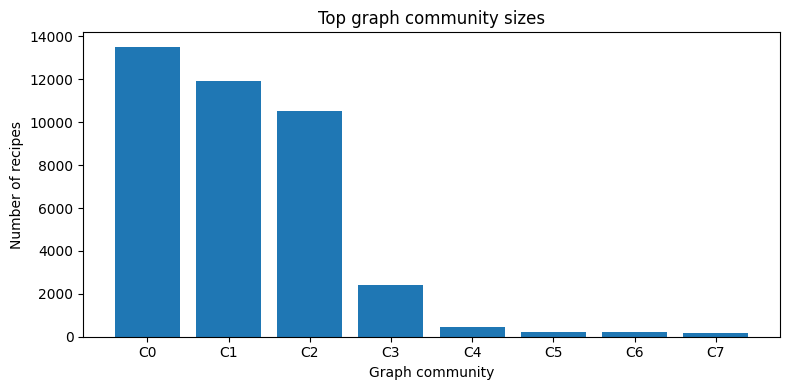

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

graph_sizes = pd.Series(graph_labels).value_counts().sort_values(ascending=False)

top_k = 8
plot_graph_sizes = graph_sizes.head(top_k)

plt.figure(figsize=(8, 4))
plt.bar(
    [f"C{c}" for c in plot_graph_sizes.index],
    plot_graph_sizes.values
)
plt.title("Top graph community sizes")
plt.xlabel("Graph community")
plt.ylabel("Number of recipes")
plt.tight_layout()
plt.show()

The community-size plot shows a very uneven structure.

The first three graph communities are much larger than the rest, so most recipes fall into a small number of broad ingredient families. After that, the community sizes drop quickly.

This supports the earlier graph summary. The ingredient graph is not splitting recipes into many balanced groups. It is organizing them into a few dominant families and a long tail of smaller, more specific ones.

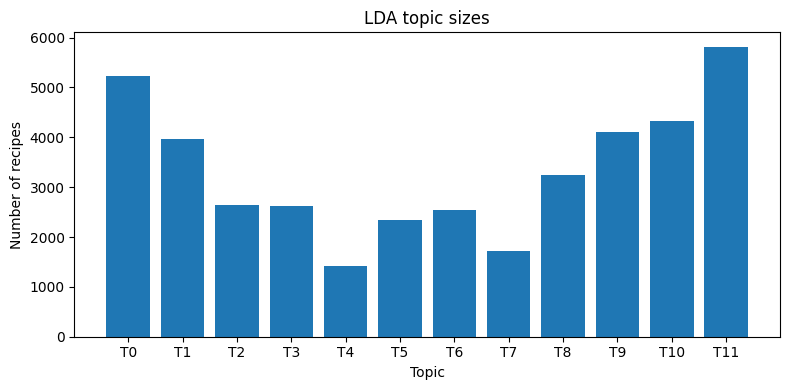

In [ ]:
topic_sizes = pd.Series(topic_labels).value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(
    [f"T{t}" for t in topic_sizes.index],
    topic_sizes.values
)
plt.title("LDA topic sizes")
plt.xlabel("Topic")
plt.ylabel("Number of recipes")
plt.tight_layout()
plt.show()

The topic-size plot is more balanced than the graph-community plot.

The LDA topics still vary in size, but the gap between the largest and smallest topics is much smaller than on the graph side. This means the text side spreads recipes across a broader set of themes, while the ingredient graph concentrates recipes into a few dominant families.

That difference helps explain why the alignment is meaningful but not one-to-one.

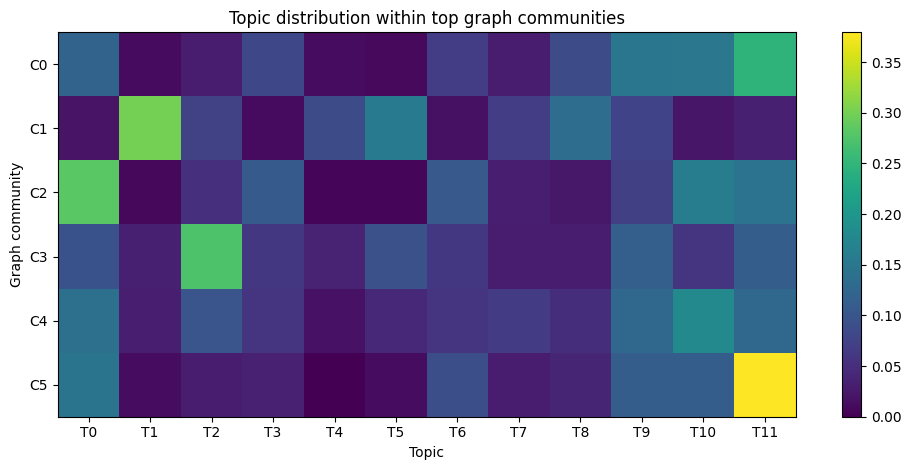

In [ ]:
import numpy as np

# top 6 graph communities only, so the plot stays readable
top_graph_comms = graph_sizes.head(6).index.tolist()

ct_top = ct.loc[top_graph_comms]

# row-normalized so each row sums to 1
ct_top_row = ct_top.div(ct_top.sum(axis=1), axis=0)

plt.figure(figsize=(10, 4.8))
im = plt.imshow(ct_top_row.values, aspect="auto")
plt.colorbar(im)

plt.xticks(
    range(len(ct_top_row.columns)),
    [f"T{t}" for t in ct_top_row.columns]
)
plt.yticks(
    range(len(ct_top_row.index)),
    [f"C{c}" for c in ct_top_row.index]
)

plt.xlabel("Topic")
plt.ylabel("Graph community")
plt.title("Topic distribution within top graph communities")
plt.tight_layout()
plt.show()

The heatmap shows the topic distribution inside the largest ingredient communities.

The alignment is clear, but it is not one-to-one. Community C0 is led by T11, but it also has visible mass on T10 and T9. Community C1 is led by T1, but it also spreads into T5 and T8. Community C2 is led by T0, but it also has visible mass on T10 and T11.

Smaller communities can be more focused. For example, C5 is much more concentrated on T11 than the largest communities are on their dominant topics.

This is the main RQ3 result. Ingredient similarity recovers broad recipe families, but those families still spread across several text themes.

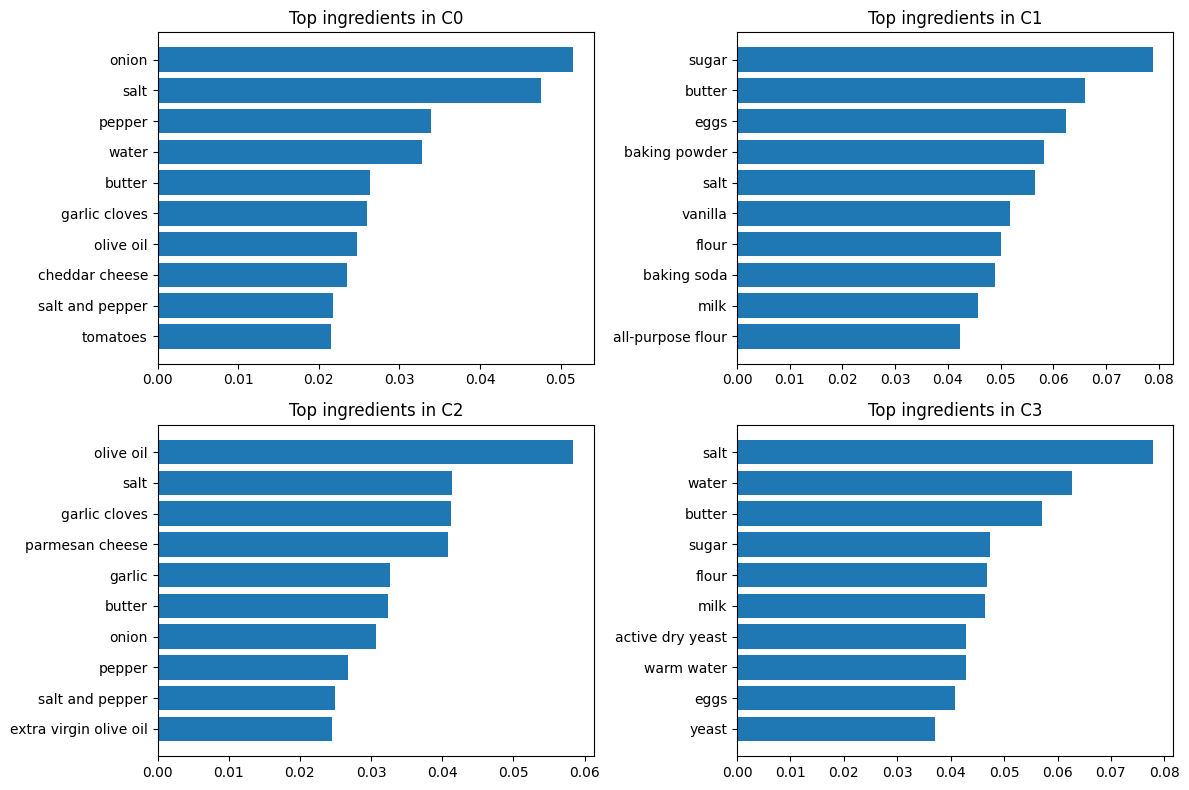

In [ ]:
vec_ing_top = TfidfVectorizer(
    tokenizer=identity,
    preprocessor=identity,
    token_pattern=None,
    lowercase=False,
    min_df=10
)

X_ing_top = vec_ing_top.fit_transform(rq3_final["ingredients_list_raw"])
feat_names = np.array(vec_ing_top.get_feature_names_out())

top_graph_comms = graph_sizes.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, cid in zip(axes, top_graph_comms):
    idx = np.where(graph_labels == cid)[0]
    mean_tfidf = np.asarray(X_ing_top[idx].mean(axis=0)).ravel()
    top_idx = np.argsort(mean_tfidf)[::-1][:10]

    ax.barh(range(10), mean_tfidf[top_idx][::-1])
    ax.set_yticks(range(10))
    ax.set_yticklabels(feat_names[top_idx][::-1])
    ax.set_title(f"Top ingredients in C{cid}")

plt.tight_layout()
plt.show()

The top-ingredient plots make the graph communities easier to interpret.

C0 is a broad savory pantry community with onion, salt, pepper, water, garlic, olive oil, and tomatoes. C1 is a dessert-baking community with sugar, butter, eggs, baking powder, vanilla, flour, and baking soda. C2 is another savory main-dish community centered on olive oil, garlic, parmesan, butter, and onion. C3 is a bread and dough community built around flour, water, yeast, sugar, and eggs.

This matches the representative recipes shown earlier and helps explain why the graph communities align with soups, desserts, savory mains, and breads rather than with one exact recipe type.

### Conclusion

RQ3 showed that ingredient-similarity communities and text topics do align, but mainly at the level of broad recipe families rather than exact one-to-one categories.

The ingredient graph recovered clear families such as soups and stews, dessert baking, savory pasta and skillet dishes, breads, and salads. The text topics supported these interpretations, and the representative recipes made the identities of the largest communities easy to read.

At the same time, the alignment was only partial. The largest ingredient communities still spread across several topics, and the topic-size plot was more balanced than the graph-community plot. This means ingredient similarity is useful for recovering broad recipe families, but it does not fully determine one text theme or one exact dish type.

The main result is that ingredient similarity captures broad food families, while the text side shows that those families still branch into multiple preparation styles and presentation forms.

### Limitations and tradeoffs

RQ3 also has clear tradeoffs.

The ingredient side depends on the graph construction choices, especially TF-IDF weighting and the value of `k` in the k-nearest-neighbor graph. Different graph settings could change the community structure.

The text side depends on topic-modeling choices such as the number of topics, stopword handling, and the decision to remove ingredient words from the step text. I used the ingredient-removed version as the main result because it is more principled, but the final scores still depend on this representation choice.

The analysis also uses a large sample rather than the full dataset. That keeps the graph and topic-modeling steps manageable, but it means the exact community sizes and topic shares are sample-dependent.

Even with these limits, RQ3 adds something important beyond RQ1 and RQ2. It shows that ingredient similarity does recover broad recipe families, but those families remain textually diverse rather than collapsing into one narrow topic.

---

## Final takeaways and conclusion

Across all three research questions, the same high-level result appeared in different ways: ingredients matter, but they do not determine procedure in a simple one-to-one way.

RQ1 showed this at the recipe-family level. Ingredient-based clusters and step-text-based clusters had only modest overall agreement, but the overlap was not random. Baking-oriented ingredient groups aligned more clearly with baking-style procedure groups, while broad savory ingredient groups spread across several different cooking styles. RQ2 showed the same idea inside specific ingredient-defined subsets. Some ingredient sets behaved almost like a blueprint. More specific baking triples such as egg + sugar + vanilla were strongly tied to narrow recurring subsequences like `mix -> bake`, often followed by `bake -> chill`. Other ingredient sets, such as garlic + olive oil + onion, still had recurring structure, but supported a broader set of step patterns such as `mix -> simmer` and `simmer -> serve`. RQ3 showed the same pattern again at a broader semantic level. Ingredient-similarity communities aligned with text topics mainly at the level of broad food families such as soups, desserts, breads, salads, and savory mains, but even the largest ingredient communities still spread across multiple topics.

Taken together, these results show that ingredient structure is informative, but not sufficient by itself. If someone is making a cake, muffin, cookie, or similar baked dish, the ingredient list is often very informative about the likely procedure. A recipe with ingredients like egg, sugar, vanilla, flour, and baking powder usually lands in a narrow procedural region built around batter-style mixing and baking. But if someone is cooking with a broad savory base such as garlic, onion, olive oil, salt, and water, the outcome is much less fixed. Those ingredients still carry useful signal, but they can lead to soups, stews, sauces, pasta dishes, skillet meals, salads, and other different outcomes. In other words, some ingredient sets act almost like a recipe blueprint, while others define a broader cooking space with multiple valid procedural paths.

This project also showed why it was useful to study the same dataset through several data mining methods instead of relying on a single technique. Clustering revealed family-level overlap, frequent itemset mining and sequence mining showed how specific ingredient sets connect to recurring action patterns, and graph communities plus topic modeling showed how ingredient similarity relates to broader dish-level themes. Looking at all three together made the main conclusion much stronger than any single result alone.

There are still clear tradeoffs and limitations. Ingredient representations simplify food identity, and stronger normalization helps some methods more than others. Step-text representations and action-sequence representations both simplify procedure in different ways. Several results also depend on modeling choices such as support thresholds, topic count, graph construction, and the selected itemsets used for detailed analysis. Even with these limitations, the overall pattern was stable: ingredient similarity organizes recipe space, but the strength of its connection to procedure depends on the part of the recipe space being studied.

A natural next step would be to use richer ingredient families and richer procedural representations. For example, future work could distinguish ingredient roles such as aromatic base, sweetener, flour type, dairy, or protein, and could model finer-grained cooking steps such as marinating, proofing, reducing, blending, or layering. Another useful direction would be to apply these ideas to recipe recommendation or recipe generation. If a system knows that some ingredient sets imply a narrow procedure while others allow several different procedural paths, it could generate better recipe suggestions, substitutions, and meal-planning options. Overall, the project suggests that recipe data has a layered structure: ingredients, procedures, and broader recipe themes are related, but they are not interchangeable.

```
On my honor, I declare the following resources:
1. Collaborators:
None

2. Web Sources:
https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions/data

3. AI Tools:
Used ChatGPT to generate code for the several aspects of this project during analysis and experimentation. I also used chatgpt to understand few external methodologies like topic modeling and prefix span. I also used it to paraphrase my observations and written descriptions to be formatted in an ordered way.

4. Citations: None
```